In [92]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
from check_time import extract_vars
import seaborn as sns

In [2]:
"""# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client"""

'# dask\nimport dask\nimport dask.array as da\nimport distributed\nfrom dask.distributed import Client\n\nclient = Client()\nclient'

In [3]:
#client.close()

In [4]:
# Extracted: SO2, H2SO4, mmr_SULFATE, TROP_P
"""
extract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",
             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  
             ystart=1975,
             yend=2014,
             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",
             ow=True)
             #client = Client()
"""

'\nextract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",\n             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  \n             ystart=1975,\n             yend=2014,\n             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",\n             ow=True)\n             #client = Client()\n'

In [5]:
#client.close()

In [6]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)
"""
shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)"""

"\nshifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])\nds_19 = ds_19.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])\nds_22 = ds_22.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])\nds_19_c = ds_19_c.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])\nds_24 = ds_24.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])\nds_1825 = ds_1825.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])\nds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])\nds_1tg = ds_1tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_mo

### Sulfate burden and SO2 concentrations

In [7]:
"""lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))"""

'lat = ds_19["lat"]\nweighted_lat = np.cos(np.deg2rad(lat))\nlat_22 = ds_22["lat"]\nweighted_lat_22 = np.cos(np.deg2rad(lat_22))\nlat_19_c = ds_19_c["lat"]\nweighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))\nlat_24 = ds_24["lat"]\nweighted_lat_24 = np.cos(np.deg2rad(lat_24))\nlat_1825 = ds_1825["lat"]\nweighted_lat_1825 = np.cos(np.deg2rad(lat_1825))\nlat_1825_17tg = ds_1825_17tg["lat"]\nweighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))\nlat_1tg = ds_1tg["lat"]\nweighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))\nlat_1pr = ds_1pr["lat"]\nweighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))\nlat_60tg = ds_60tg["lat"]\nweighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))'

In [8]:
so2_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/SO2_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in so2_19['time'].values])
so2_19 = so2_19.assign_coords(time=shifted_time_19)
so2_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/SO2_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in so2_19_c['time'].values])
so2_19_c = so2_19_c.assign_coords(time=shifted_time_19_c)
so2_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/SO2_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in so2_22['time'].values])
so2_22 = so2_22.assign_coords(time=shifted_time_22)
so2_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/SO2_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in so2_24['time'].values])
so2_24 = so2_24.assign_coords(time=shifted_time_24)
so2_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/SO2_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in so2_1825_17tg['time'].values])
so2_1825_17tg = so2_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
so2_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/SO2_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in so2_1825['time'].values])
so2_1825 = so2_1825.assign_coords(time=shifted_time_1825)
so2_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/SO2_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in so2_1tg['time'].values])
so2_1tg = so2_1tg.assign_coords(time=shifted_time_1tg)
so2_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/SO2_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in so2_1pr['time'].values])
so2_1pr = so2_1pr.assign_coords(time=shifted_time_1pr)
so2_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/SO2_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in so2_60tg['time'].values])
so2_60tg = so2_60tg.assign_coords(time=shifted_time_60tg)

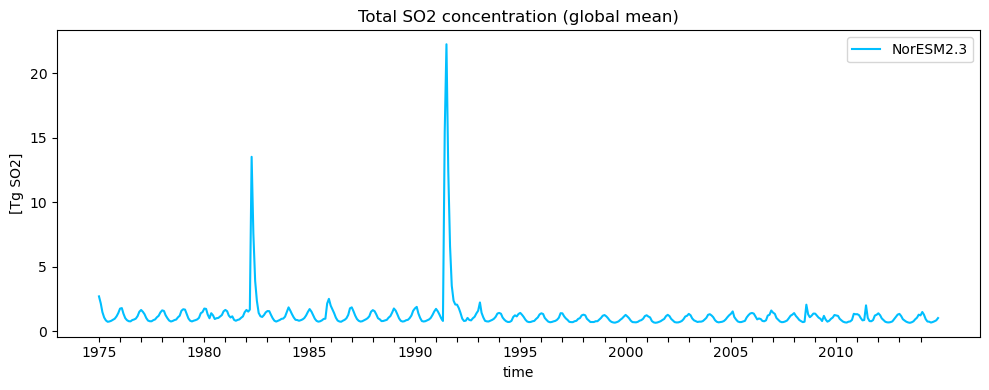

In [9]:
M_SO2 = 64.066     
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K_so2 = (M_SO2 / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

lat = so2_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = so2_19["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

so2_tg = so2 * K_so2

plt.figure(figsize=(10, 4))
so2_tg.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[Tg SO2]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

In [11]:
lat = so2_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = so2_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = so2_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = so2_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = so2_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = so2_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = so2_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = so2_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [12]:
def plot_so2_lev_time(ds, weighted_lat, ax=None, title=None, add_colorbar=True):
    so2_profile = ds["SO2"].weighted(weighted_lat)
    so2_time_lev = so2_profile.mean(dim=['lat', 'lon'])
    so2_zoom = so2_time_lev.sel(time=slice('1991-01-01', '1992-12-30'))
    lev_pa = ds['lev'] * 100 
    
    delta_p = np.abs(np.gradient(lev_pa.values)) 
    
    total_area = 4 * np.pi * (6.371e6)**2
    M_layer = (delta_p / 9.80665) * total_area
    
    faktor_s = 32.06 / 28.97
    M_layer_da = xr.DataArray(M_layer, coords=[ds['lev']], dims=['lev'])
    so2_tg_s = (so2_zoom * faktor_s * M_layer_da) / 1e9

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    p = so2_tg_s.T.plot(
        ax=ax,
        x="time",
        y="lev",
        #levels=21,
        cmap="plasma",
        add_colorbar=add_colorbar,
        extend="max",
        cbar_kwargs={
            "label": "SO$_2$ Mass [Tg S]",
            "shrink": 0.8,
            "pad": 0.02
        } if add_colorbar else None
    )

    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_ylabel(" ")
    ax.set_xlabel(" ")

    if title:
        ax.set_title(title)

    return ax

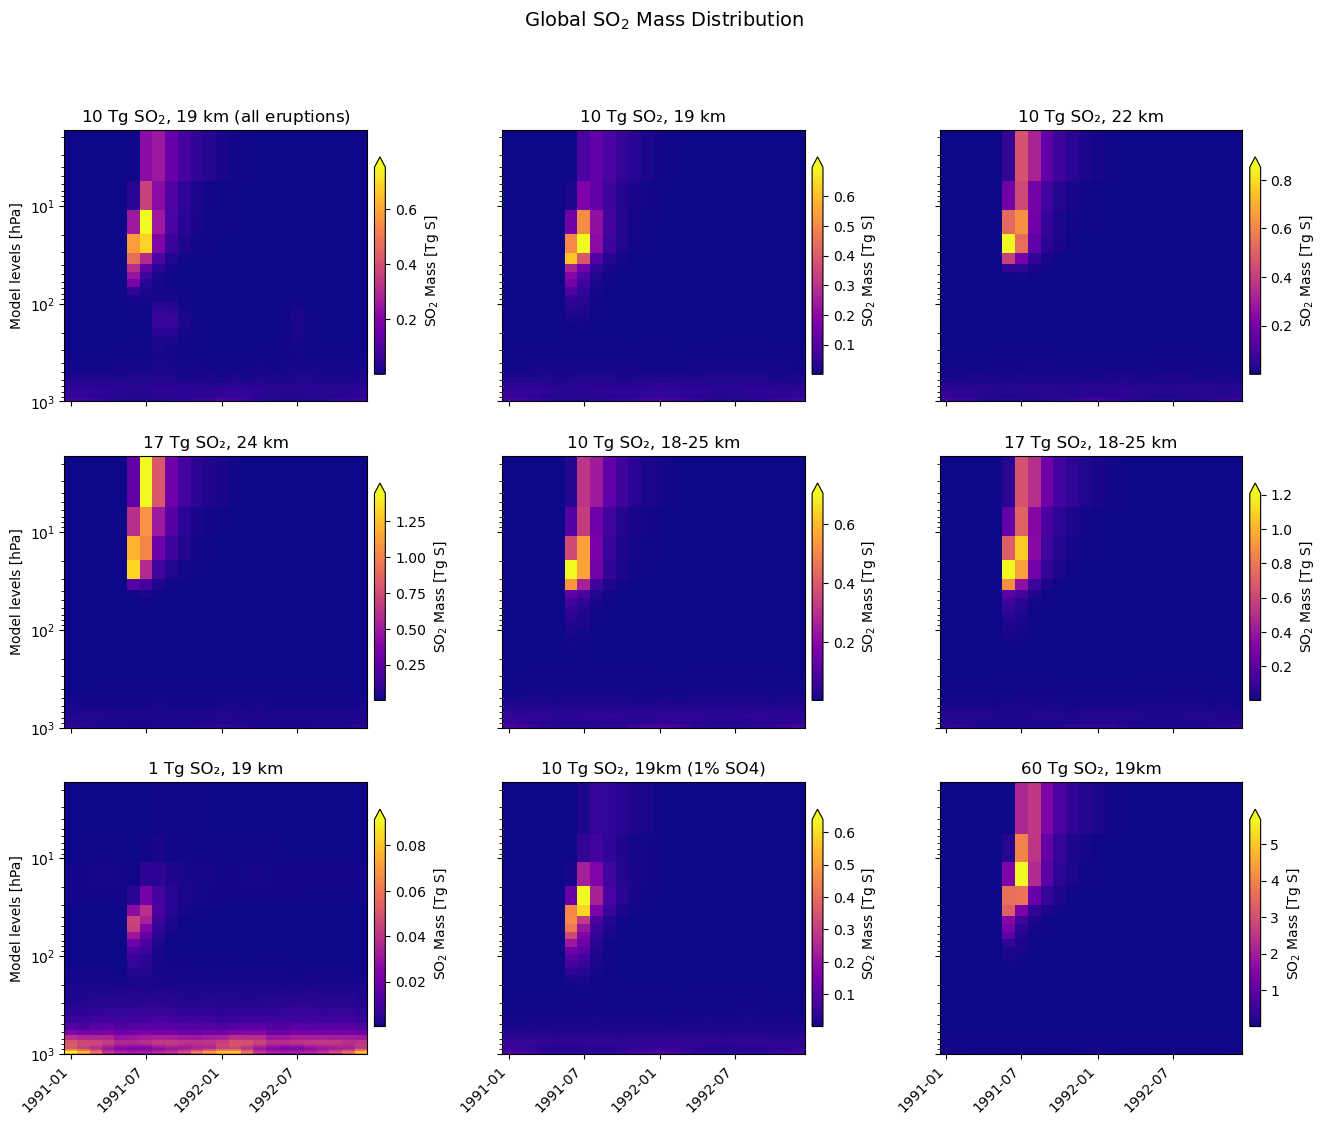

In [93]:
datasets = [so2_19, so2_19_c, so2_22, so2_24, so2_1825, so2_1825_17tg, so2_1tg, so2_1pr, so2_60tg]
weighted_ds = [weighted_lat, weighted_lat_19_c, weighted_lat_22, weighted_lat_24, weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1tg, weighted_lat_1pr, weighted_lat_60tg]
titles = [
    "10 Tg SO$_2$, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km",
    "10 Tg SO₂, 19km (1% SO4)",
    "60 Tg SO₂, 19km"
]


fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, ax in enumerate(axs.flat):
    if i < len(datasets):
        plot_so2_lev_time(datasets[i], weighted_ds[i], ax=ax, title=titles[i])

for ax in axs[:, 0]:
    ax.set_ylabel("Model levels [hPa]")
for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle("Global SO$_2$ Mass Distribution", fontsize=14)

#plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.92])
plt.show()

### H2SO4 and sulfate

In [14]:
h2so4_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/H2SO4_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in h2so4_19['time'].values])
h2so4_19 = h2so4_19.assign_coords(time=shifted_time_19)
h2so4_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/H2SO4_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in h2so4_19_c['time'].values])
h2so4_19_c = h2so4_19_c.assign_coords(time=shifted_time_19_c)
h2so4_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/H2SO4_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in h2so4_22['time'].values])
h2so4_22 = h2so4_22.assign_coords(time=shifted_time_22)
h2so4_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/H2SO4_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in h2so4_24['time'].values])
h2so4_24 = h2so4_24.assign_coords(time=shifted_time_24)
h2so4_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/H2SO4_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in h2so4_1825_17tg['time'].values])
h2so4_1825_17tg = h2so4_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
h2so4_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/H2SO4_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in h2so4_1825['time'].values])
h2so4_1825 = h2so4_1825.assign_coords(time=shifted_time_1825)
h2so4_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/H2SO4_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in h2so4_1tg['time'].values])
h2so4_1tg = h2so4_1tg.assign_coords(time=shifted_time_1tg)
h2so4_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/H2SO4_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in h2so4_1pr['time'].values])
h2so4_1pr = h2so4_1pr.assign_coords(time=shifted_time_1pr)
h2so4_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/H2SO4_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in h2so4_60tg['time'].values])
h2so4_60tg = h2so4_60tg.assign_coords(time=shifted_time_60tg)

Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

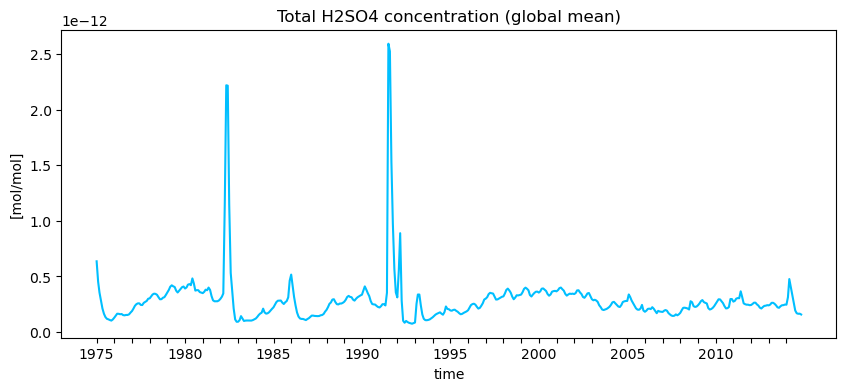

In [15]:
so4 = h2so4_19["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

In [16]:
mmr_SULFATE_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/mmr_SULFATE_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_19['time'].values])
mmr_SULFATE_19 = mmr_SULFATE_19.assign_coords(time=shifted_time_19)
mmr_SULFATE_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in mmr_SULFATE_19_c['time'].values])
mmr_SULFATE_19_c = mmr_SULFATE_19_c.assign_coords(time=shifted_time_19_c)
mmr_SULFATE_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_22['time'].values])
mmr_SULFATE_22 = mmr_SULFATE_22.assign_coords(time=shifted_time_22)
mmr_SULFATE_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_24['time'].values])
mmr_SULFATE_24 = mmr_SULFATE_24.assign_coords(time=shifted_time_24)
mmr_SULFATE_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1825_17tg['time'].values])
mmr_SULFATE_1825_17tg = mmr_SULFATE_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
mmr_SULFATE_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1825['time'].values])
mmr_SULFATE_1825 = mmr_SULFATE_1825.assign_coords(time=shifted_time_1825)
mmr_SULFATE_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1tg['time'].values])
mmr_SULFATE_1tg = mmr_SULFATE_1tg.assign_coords(time=shifted_time_1tg)
mmr_SULFATE_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1pr['time'].values])
mmr_SULFATE_1pr = mmr_SULFATE_1pr.assign_coords(time=shifted_time_1pr)
mmr_SULFATE_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_60tg['time'].values])
mmr_SULFATE_60tg = mmr_SULFATE_60tg.assign_coords(time=shifted_time_60tg)

Text(0.5, 1.0, 'Mass mixing ratio of Sulfate (global mean)')

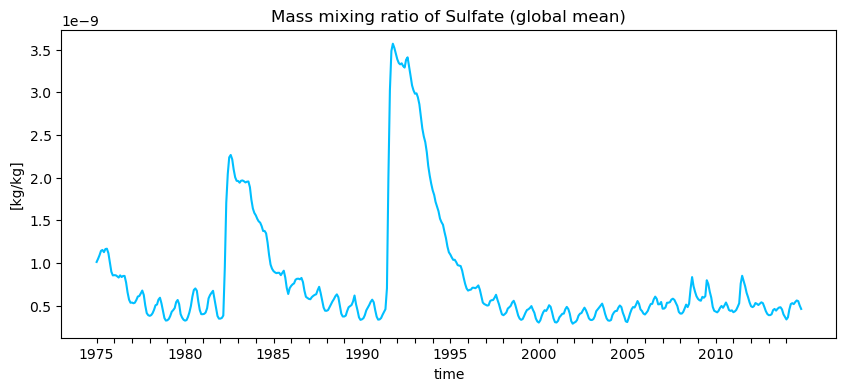

In [17]:
def get_weighted(ds, lat_min=-90, lat_max=90):
    ds_area = ds.sel(lat=slice(lat_min, lat_max))
    
    weights_lat = np.cos(np.deg2rad(ds_area.lat))
    weights_lat.name = "weights"
    
    lev_vals = ds_area.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': ds_area.lev}, dims=['lev'])
    ds_h = ds.weighted(weights_lat).mean(dim=["lat", "lon"])
    ds_final = ds_h.weighted(wl).mean(dim="lev")
    
    return ds_final

mmr_so4 = mmr_SULFATE_19["mmr_SULFATE"] #.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
mmr_so4 = get_weighted(mmr_so4)

plt.figure(figsize=(10, 4))
mmr_so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[kg/kg]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Mass mixing ratio of Sulfate (global mean)")

In [18]:
trop_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TROP_P_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in trop_19['time'].values])
trop_19 = trop_19.assign_coords(time=shifted_time_19)
trop_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TROP_P_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in trop_19_c['time'].values])
trop_19_c = trop_19_c.assign_coords(time=shifted_time_19_c)
trop_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TROP_P_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in trop_22['time'].values])
trop_22 = trop_22.assign_coords(time=shifted_time_22)
trop_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TROP_P_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in trop_24['time'].values])
trop_24 = trop_24.assign_coords(time=shifted_time_24)
trop_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in trop_1825_17tg['time'].values])
trop_1825_17tg = trop_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
trop_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in h2so4_1825['time'].values])
trop_1825 = trop_1825.assign_coords(time=shifted_time_1825)
trop_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TROP_P_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in trop_1tg['time'].values])
trop_1tg = trop_1tg.assign_coords(time=shifted_time_1tg)
trop_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TROP_P_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in trop_1pr['time'].values])
trop_1pr = trop_1pr.assign_coords(time=shifted_time_1pr)
trop_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TROP_P_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in trop_60tg['time'].values])
trop_60tg = trop_60tg.assign_coords(time=shifted_time_60tg)

In [19]:
tropopause = trop_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22 = trop_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = trop_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = trop_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = trop_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = trop_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = trop_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= trop_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= trop_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

In [20]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

In [21]:
def get_sulfur_timeseries(ds, plev):
    levs = ds.lev.values
    lats = ds.lat.values
    lons = ds.lon.values
    times = ds.time.values
    
    g = 9.80665
    R = 6.371e6
    c = 32.065 / 96.06  
    
    weights_lat = np.cos(np.deg2rad(lats))
    dlat = np.deg2rad(np.abs(np.nanmedian(np.diff(lats))))
    dlon = np.deg2rad(np.abs(np.nanmedian(np.diff(lons))))
    cell_area = weights_lat[:, None] * dlat * dlon * (R**2)
    
    interfaces = np.zeros(len(levs) + 1)
    interfaces[1:-1] = (levs[:-1] + levs[1:]) / 2
    interfaces[0] = levs[0] - (levs[1] - levs[0])/2
    interfaces[-1] = levs[-1] + (levs[-1] - levs[-2])/2
    dp_vals = np.abs(np.diff(interfaces)) * 100  
    
    p_lev = plev.copy()
    if np.nanmean(p_lev) > 2000: 
        p_lev = p_lev / 100.0
        
    tg_s_series = np.zeros(len(times))
    
    for t in range(len(times)):
        mmr_t = ds["mmr_SULFATE"].isel(time=t).values
        
        if hasattr(p_lev, "dims"):
            p_limit_t = p_lev.isel(time=t).values if "time" in p_lev.dims else p_lev.values
        else:
            p_limit_t = p_lev
            
        total_mass_kg = 0
        
        for i in range(len(levs)):
            mask_layer = (levs[i] <= p_limit_t)
            
            layer_mass = np.nansum(mmr_t[i, :, :] * (dp_vals[i] / g) * cell_area * mask_layer)
            total_mass_kg += layer_mass
            
        tg_s_series[t] = total_mass_kg * 1e-9 * c
        
    return tg_s_series



In [22]:
mmr_SULFATE_19_pin = mmr_SULFATE_19.sel(time=slice("1991", "1995"))
so4_series_19 = get_sulfur_timeseries(mmr_SULFATE_19_pin, p_lev)
so4_series_19_c = get_sulfur_timeseries(mmr_SULFATE_19_c, p_lev_19_c)
so4_series_22 = get_sulfur_timeseries(mmr_SULFATE_22, p_lev_22)
so4_series_24 = get_sulfur_timeseries(mmr_SULFATE_24, p_lev_24)
so4_series_1825 = get_sulfur_timeseries(mmr_SULFATE_1825, p_lev_1825)
so4_series_1825_17tg = get_sulfur_timeseries(mmr_SULFATE_1825_17tg, p_lev_1825_17tg)
so4_series_1pr = get_sulfur_timeseries(mmr_SULFATE_1pr, p_lev_1pr)
so4_series_1tg = get_sulfur_timeseries(mmr_SULFATE_1tg, p_lev_1tg)
so4_series_60tg = get_sulfur_timeseries(mmr_SULFATE_60tg, p_lev_60tg)

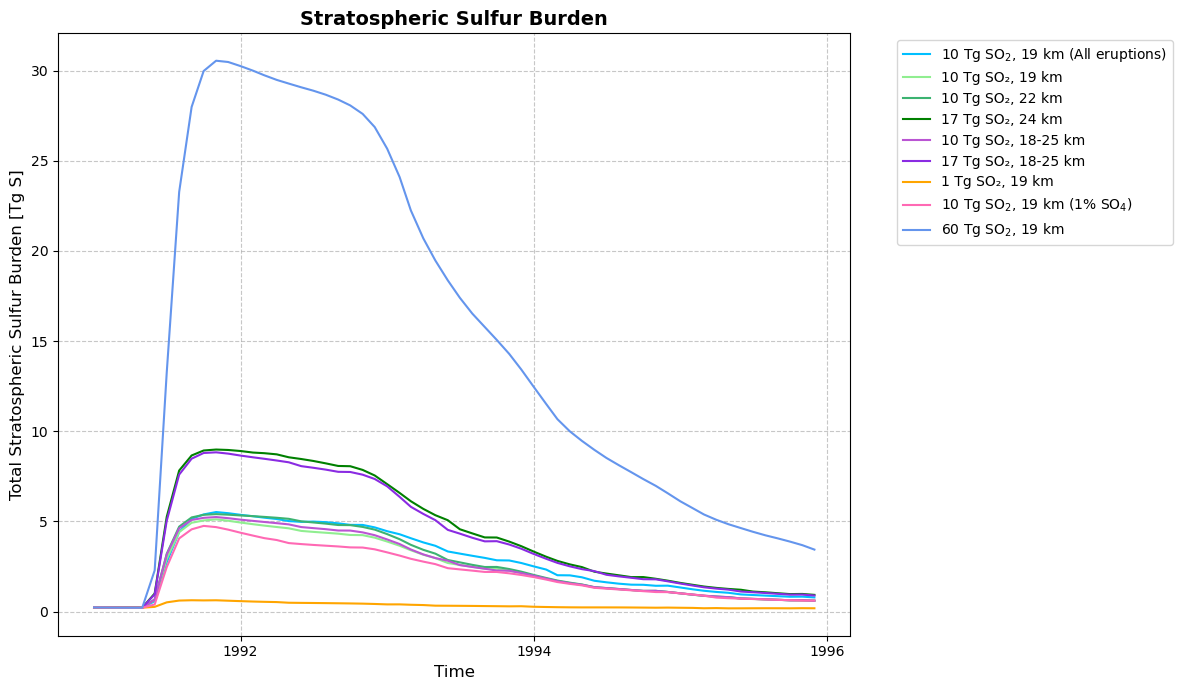

In [23]:
datasets = [mmr_SULFATE_19_c, mmr_SULFATE_22, mmr_SULFATE_24, mmr_SULFATE_1825, mmr_SULFATE_1825_17tg, mmr_SULFATE_1tg, mmr_SULFATE_1pr, mmr_SULFATE_60tg]
plev = [p_lev_19_c, p_lev_22, p_lev_24, p_lev_1825, p_lev_1825_17tg, p_lev_1tg, p_lev_1pr, p_lev_60tg]
titles = [
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km", 
    "10 Tg SO$_2$, 19 km (1% SO$_4$)",
    "60 Tg SO$_2$, 19 km"
]
colors = ["lightgreen",
          "mediumseagreen",
          "green",
          "mediumorchid",
          "blueviolet",
          "orange",
          "hotpink",
          "cornflowerblue"]

plt.figure(figsize=(12, 7))
plt.plot(mmr_SULFATE_19_pin.time, so4_series_19, color = "deepskyblue", label = "10 Tg SO$_2$, 19 km (All eruptions)")
for ds, p, title, c in zip(datasets, plev, titles, colors):
    ssb = get_sulfur_timeseries(ds, p)
    plt.plot(ds.time, ssb, color = c, label=title, linewidth=1.5)

plt.title("Stratospheric Sulfur Burden", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Total Stratospheric Sulfur Burden [Tg S]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()

plt.show()

In [24]:
def get_sulfur_timeseries_tropics(ds, p_lev_input):
    ds_trop = ds.sel(lat=slice(-20, 20))
    
    levs = ds_trop.lev.values
    lats = ds_trop.lat.values
    lons = ds_trop.lon.values
    times = ds_trop.time.values
    
    g = 9.80665
    R = 6.371e6
    c = 32.065 / 96.06 
    
    weights_lat = np.cos(np.deg2rad(lats))
    dlat = np.deg2rad(np.abs(np.nanmedian(np.diff(lats))))
    dlon = np.deg2rad(np.abs(np.nanmedian(np.diff(lons))))
    cell_area = weights_lat[:, None] * dlat * dlon * (R**2)
    
    interfaces = np.zeros(len(levs) + 1)
    interfaces[1:-1] = (levs[:-1] + levs[1:]) / 2
    interfaces[0] = levs[0] - (levs[1] - levs[0])/2
    interfaces[-1] = levs[-1] + (levs[-1] - levs[-2])/2
    dp_vals = np.abs(np.diff(interfaces)) * 100 
    
    p_lev = p_lev_input.copy()
    if hasattr(p_lev, "lat"):
        p_lev = p_lev.sel(lat=slice(-20, 20))
    if np.nanmean(p_lev) > 2000: 
        p_lev = p_lev / 100.0
        
    tg_s_series = np.zeros(len(times))
    
    for t in range(len(times)):
        mmr_t = ds_trop["mmr_SULFATE"].isel(time=t).values
        
        if hasattr(p_lev, "dims"):
            p_limit_t = p_lev.isel(time=t).values if "time" in p_lev.dims else p_lev.values
        else:
            p_limit_t = p_lev
            
        total_mass_kg = 0
        for i in range(len(levs)):
            mask_layer = (levs[i] <= p_limit_t)
            layer_mass = np.nansum(mmr_t[i, :, :] * (dp_vals[i] / g) * cell_area * mask_layer)
            total_mass_kg += layer_mass
            
        tg_s_series[t] = total_mass_kg * 1e-9 * c
        
    return tg_s_series


so4_series_trop_19 = get_sulfur_timeseries_tropics(mmr_SULFATE_19_pin, p_lev)
so4_series_trop_19_c = get_sulfur_timeseries_tropics(mmr_SULFATE_19_c, p_lev_19_c)
so4_series_trop_22 = get_sulfur_timeseries_tropics(mmr_SULFATE_22, p_lev_22)
so4_series_trop_24 = get_sulfur_timeseries_tropics(mmr_SULFATE_24, p_lev_24)
so4_series_trop_1825 = get_sulfur_timeseries_tropics(mmr_SULFATE_1825, p_lev_1825)
so4_series_trop_1825_17tg = get_sulfur_timeseries_tropics(mmr_SULFATE_1825_17tg, p_lev_1825_17tg)
so4_series_trop_1pr = get_sulfur_timeseries_tropics(mmr_SULFATE_1pr, p_lev_1pr)
so4_series_trop_1tg = get_sulfur_timeseries_tropics(mmr_SULFATE_1tg, p_lev_1tg)
so4_series_trop_60tg = get_sulfur_timeseries_tropics(mmr_SULFATE_60tg, p_lev_60tg)

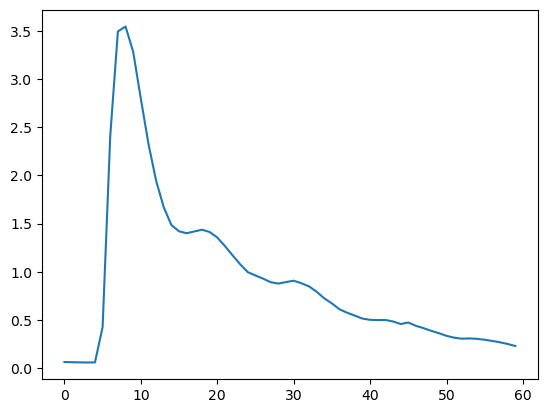

In [25]:
plt.plot(so4_series_trop_19)

In [26]:
background = get_sulfur_timeseries(mmr_SULFATE_19.sel(time=slice("1986-01", "1990-12")), p_lev)
background_trop = get_sulfur_timeseries_tropics(mmr_SULFATE_19.sel(time=slice("1986-01", "1990-12")), p_lev)

In [27]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"

In [28]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

/tmp/ipykernel_2927493/1286819563.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_2927493/1286819563.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

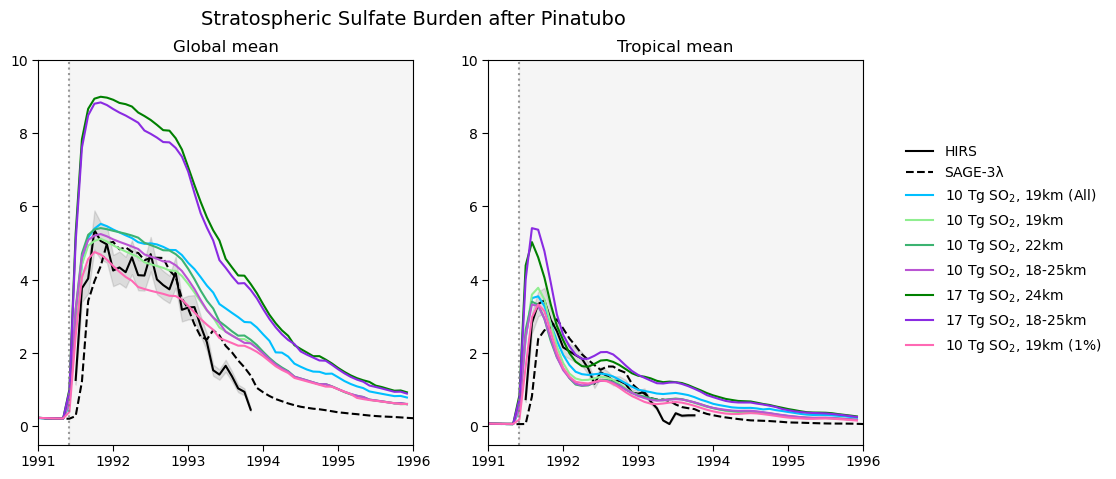

In [29]:
total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)
total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)

def get_decimal_years(ds):
    return np.array([t.year + (t.month-1)/12 for t in ds.time.values])

t_19 = get_decimal_years(mmr_SULFATE_19_pin)
t_22 = get_decimal_years(mmr_SULFATE_22)
t_24 = get_decimal_years(mmr_SULFATE_24)
t_1825 = get_decimal_years(mmr_SULFATE_1825)
t_17_18 = get_decimal_years(mmr_SULFATE_1825_17tg)
t_1tg = get_decimal_years(mmr_SULFATE_1tg)
t_1pr = get_decimal_years(mmr_SULFATE_1pr)
t_60 = get_decimal_years(mmr_SULFATE_60tg)

obs_time = np.array([t.year + (t.month-1)/12 for t in total_sage.index])
obs_time_hirs = np.array([t.year + (t.month-1)/12 for t in total.index])


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(obs_time_hirs, total, color="black", label="HIRS")
ax[0].fill_between(obs_time_hirs, total - err_total, total + err_total, color="black", alpha=0.1)
ax[0].plot(obs_time, total_sage, color="black", linestyle="--", label="SAGE-3λ")
ax[0].plot(t_19, so4_series_19, color="deepskyblue", label="10 Tg SO$_2$, 19km (All)")
ax[0].plot(t_19, so4_series_19_c, color="lightgreen", label="10 Tg SO$_2$, 19km")
ax[0].plot(t_22, so4_series_22, color="mediumseagreen", label="10 Tg SO$_2$, 22km")
ax[0].plot(t_1825, so4_series_1825, color="mediumorchid", label="10 Tg SO$_2$, 18-25km")
ax[0].plot(t_24, so4_series_24, color="green", label="17 Tg SO$_2$, 24km")
ax[0].plot(t_17_18, so4_series_1825_17tg, color="blueviolet", label="17 Tg SO$_2$, 18-25km")
ax[0].plot(t_1pr, so4_series_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1%)")
ax[0].set_ylim(-0.5,10)
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(obs_time_hirs, trop, color="black", label="HIRS")
ax[1].fill_between(obs_time_hirs, trop - err_trop, trop + err_trop, color="black", alpha=0.1)
ax[1].plot(obs_time, trop_sage, color="black", linestyle="--", label="SAGE-3λ")
ax[1].plot(t_19, so4_series_trop_19, color="deepskyblue", label="10 Tg SO$_2$, 19km (All)")
ax[1].plot(t_19, so4_series_trop_19_c, color="lightgreen", label="10 Tg SO$_2$, 19km")
ax[1].plot(t_22, so4_series_trop_22, color="mediumseagreen", label="10 Tg SO$_2$, 22km")
ax[1].plot(t_1825, so4_series_trop_1825, color="mediumorchid", label="10 Tg SO$_2$, 18-25km")
ax[1].plot(t_24, so4_series_trop_24, color="green", label="17 Tg SO$_2$, 24km")
ax[1].plot(t_17_18, so4_series_trop_1825_17tg, color="blueviolet", label="17 Tg SO$_2$, 18-25km")
ax[1].plot(t_1pr, so4_series_trop_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1%)")
ax[1].set_ylim(-0.5,10)
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    plt.setp(a.get_xticklabels())
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric Sulfate Burden after Pinatubo", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

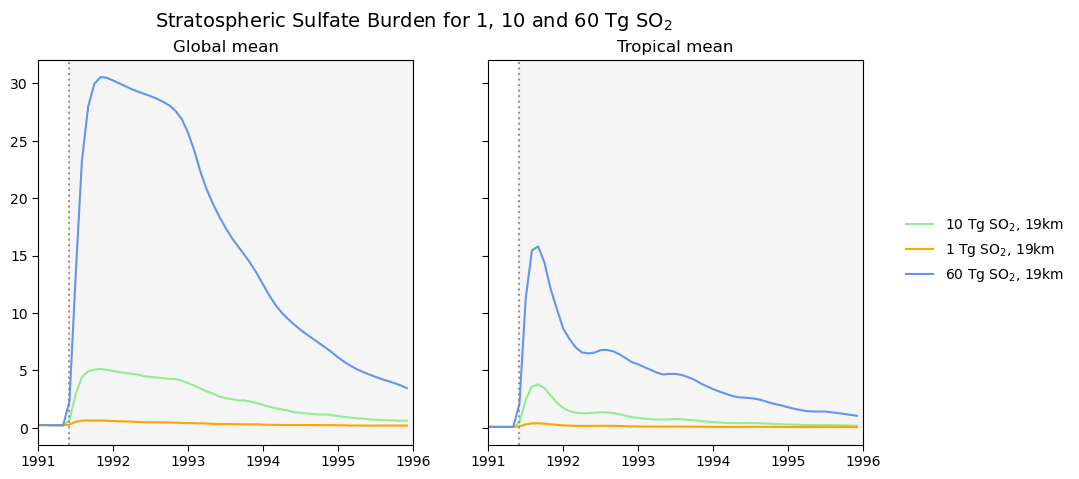

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t_19, so4_series_19_c, color="lightgreen", label="10 Tg SO$_2$, 19km")
ax[0].plot(t_1tg, so4_series_1tg, color="orange", label="1 Tg SO$_2$, 19km")
ax[0].plot(t_60, so4_series_60tg, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(t_19, so4_series_trop_19_c, color="lightgreen", label="10 Tg SO$_2$, 19km")
ax[1].plot(t_1tg, so4_series_trop_1tg, color="orange", label="1 Tg SO$_2$, 19km")
ax[1].plot(t_60, so4_series_trop_60tg, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    plt.setp(a.get_xticklabels())
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric Sulfate Burden for 1, 10 and 60 Tg SO$_2$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()


In [31]:
Mair = 28.96 # dry air

Matmos = 5.3 * 10**21

K = (Ms/Mair) * Matmos *10**(-12)
M_strat_air = 0.099 * Matmos #9.9% of the total mass of the atmosphere

Mo = 15.999

Mso4 = Ms + (4 * Mo)

c = Ms/Mso4

<Figure size 700x500 with 0 Axes>

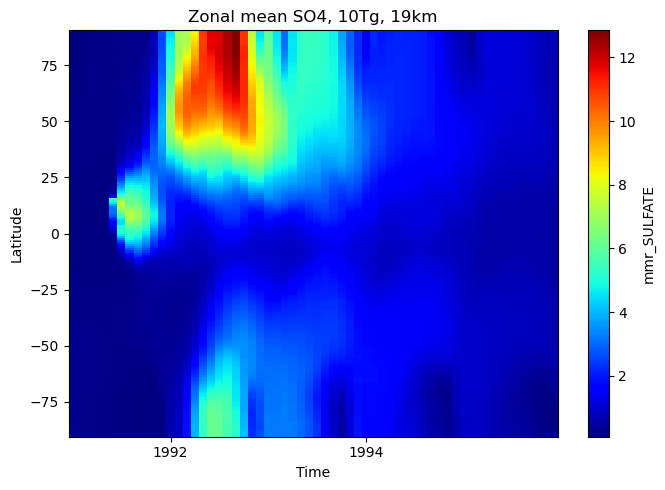

In [32]:
mmr_sulf = mmr_SULFATE_19_c["mmr_SULFATE"]
so4_burd = mmr_sulf.sel(lev=50, method="nearest")
so4_burd = so4_burd.mean(dim=["lon"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

lat = so4_burden_TgS["lat"].values

plt.figure(figsize=(7,5))
so4_burden_TgS.plot.pcolormesh(
    x="time",
    y="lat",
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO4, 10Tg, 19km")
plt.tight_layout()
plt.show()

In [33]:
def plot_so4_lat_time(ds,
    plot_period=("1991-01-01", "1996-01-01"),
    eruption_time=cftime.DatetimeNoLeap(1991, 6, 15),
    lat_marker=15,
    ax=None,
    title=None,
    add_colorbar=True,
):
    mmr_sulf = ds["mmr_SULFATE"]
    so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev).mean(dim = "lev")
    so4_burd = so4_burd.mean(dim=["lon"])
    so4_burden = so4_burd * M_strat_air *10**(-12)
    so4_burden_TgS = so4_burden * c

    so4_sel = so4_burden_TgS.sel(time=slice(*plot_period))

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = so4_sel.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap="plasma", 
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "SO4 concentration [ppb]"} if add_colorbar else None
    )

    if eruption_time is not None:
        ax.plot(
            eruption_time,
            lat_marker,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )
    ax.xaxis.set_minor_locator(mdates.YearLocator())
    ax.set_xlabel("")
    ax.set_ylabel("")

    if title:
        ax.set_title(title)

    return ax

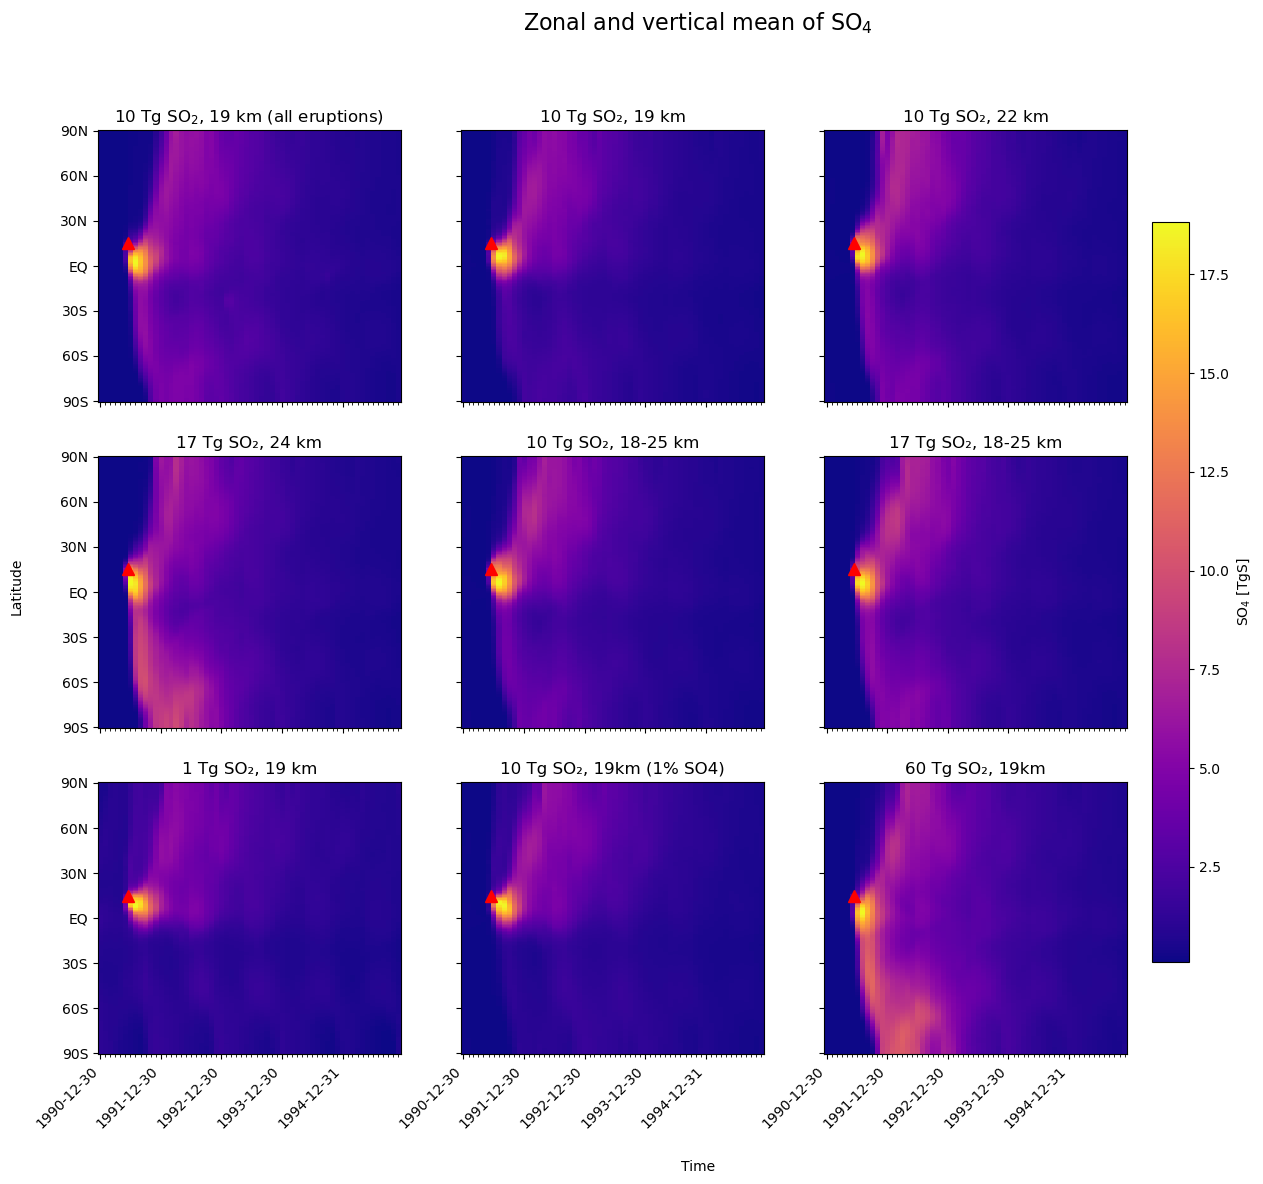

In [34]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

datasets = [mmr_SULFATE_19, mmr_SULFATE_19_c, mmr_SULFATE_22, mmr_SULFATE_24, mmr_SULFATE_1825, mmr_SULFATE_1825_17tg, mmr_SULFATE_1tg, mmr_SULFATE_1pr, mmr_SULFATE_60tg]
titles = [
    "10 Tg SO$_2$, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km",
    "10 Tg SO₂, 19km (1% SO4)",
    "60 Tg SO₂, 19km"
]

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_so4_lat_time(
        ds,
        ax=ax,
        add_colorbar=False,
        title=title,
    )
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_locator(mdates.YearLocator())


axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="SO$_4$ [TgS]",
    shrink=0.8,
    pad=0.02,
)


for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)

fig.suptitle("Zonal and vertical mean of SO$_4$", fontsize=16)
plt.show()

In [35]:
def plot_so4_lev_time(ds, weighted_ds, ax=None, title=None, add_colorbar=True):
    start = cftime.DatetimeNoLeap(1991, 1, 1)
    end = cftime.DatetimeNoLeap(1996, 1, 1)
    
    mmr_sulf = ds["mmr_SULFATE"].sel(time=slice(start, end))
    so4_mmr_global = mmr_sulf.weighted(weighted_ds).mean(dim=["lat", "lon"])
    
    lev_pa = ds.lev * 100
    delta_p = np.abs(np.gradient(lev_pa.values)) 
    air_mass_per_m2 = delta_p / 9.81
    total_area = 4 * np.pi * (6.371e6)**2
    M_layer = air_mass_per_m2 * total_area
    
    so4_tg_s = (so4_mmr_global * M_layer * c) / 1e9

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    p = so4_tg_s.T.plot(
        ax=ax, 
        x="time", 
        y="lev",
        levels = 21, 
        cmap="plasma", 
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "SO$_4$ [Tg S]", "shrink": 0.8} if add_colorbar else None
    )

    ax.set_yscale("log")
    ax.invert_yaxis()
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set_xlabel(" ") 
    ax.set_ylabel(" ")

    if title:
        ax.set_title(title, fontsize=10)

    return ax

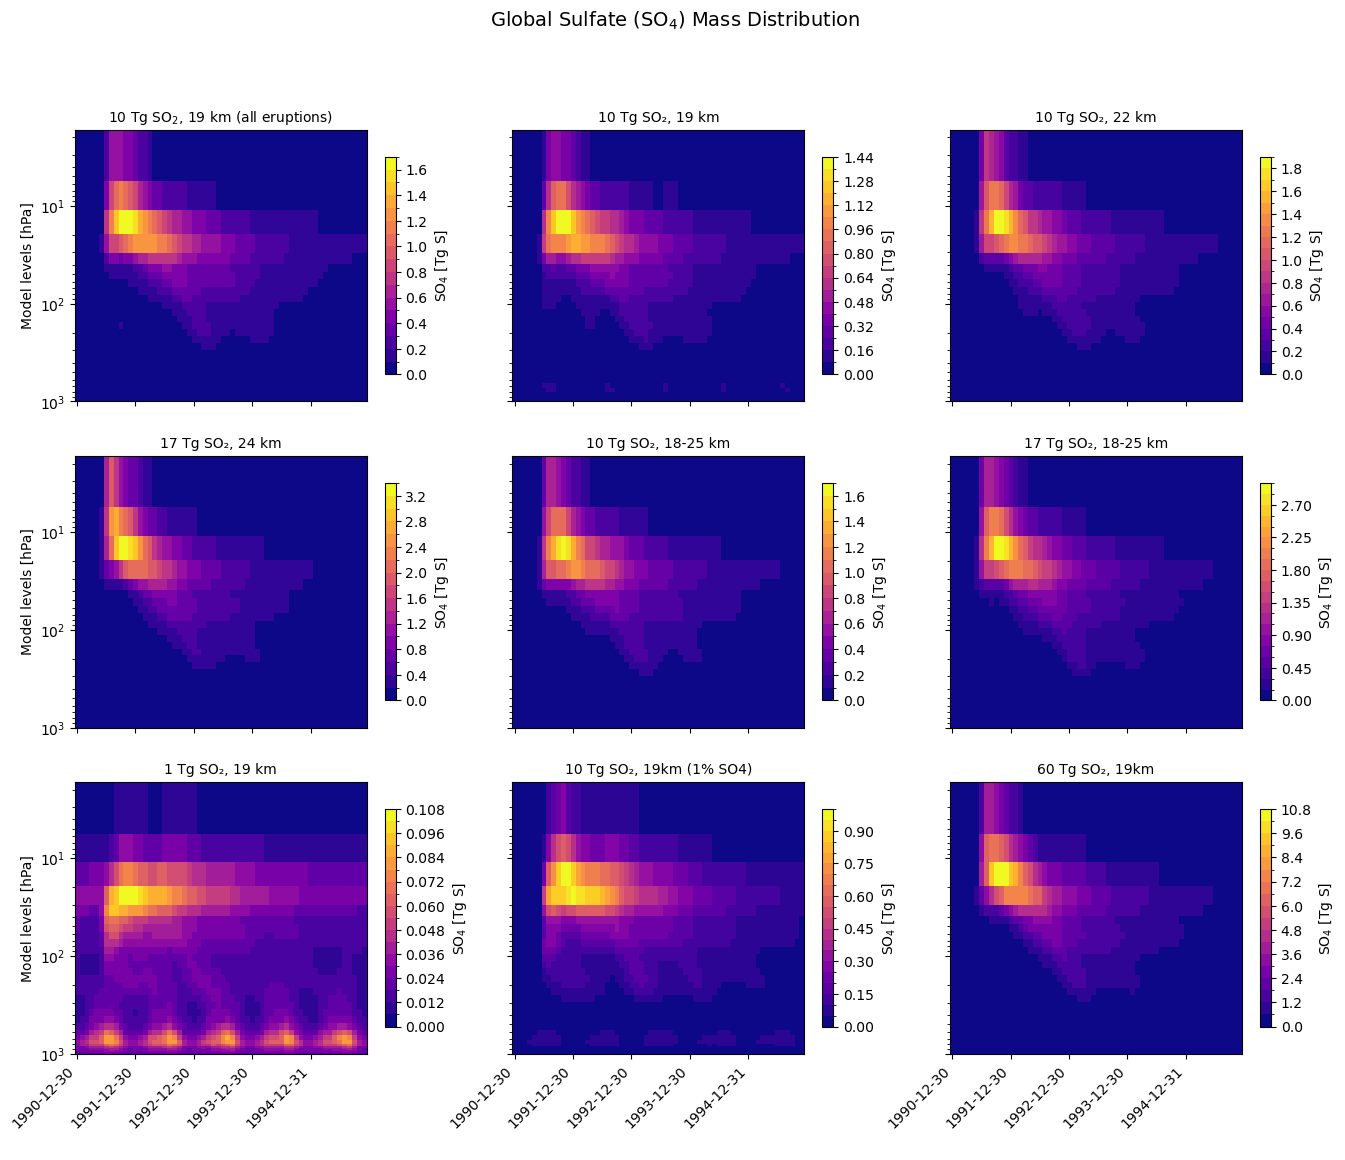

In [94]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

datasets = [mmr_SULFATE_19, mmr_SULFATE_19_c, mmr_SULFATE_22, mmr_SULFATE_24, mmr_SULFATE_1825, mmr_SULFATE_1825_17tg, mmr_SULFATE_1tg, mmr_SULFATE_1pr, mmr_SULFATE_60tg]
weighted_ds = [weighted_lat, weighted_lat_19_c, weighted_lat_22, weighted_lat_24, weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1tg, weighted_lat_1pr, weighted_lat_60tg]
titles = [
    "10 Tg SO$_2$, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km",
    "10 Tg SO₂, 19km (1% SO4)",
    "60 Tg SO₂, 19km"
]

for ax, ds, weights, title in zip(axs.flat, datasets, weighted_ds, titles):
    plot_so4_lev_time(
        ds,
        weights,
        ax=ax,
        add_colorbar=True,
        title=title,
        
    )

for ax in axs[:, 0]:
    ax.set_ylabel("Model levels [hPa]")

for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle("Global Sulfate (SO$_4$) Mass Distribution", fontsize=14)
plt.show()

In [37]:
def get_combined_s_timeseries(ds_so2, ds_mmr):
    lev_pa = ds_so2['lev'].values * 100
    dp = np.abs(np.gradient(lev_pa))
    total_area = 4 * np.pi * (6.371e6)**2
    m_layer = (dp / 9.81) * total_area
    
    weights = np.cos(np.deg2rad(ds_so2.lat))
    so2_glob = ds_so2["SO2"].weighted(weights).mean(dim=['lat', 'lon']).values
    so4_glob = ds_mmr["mmr_SULFATE"].weighted(weights).mean(dim=['lat', 'lon']).values

    f_so2 = (32.06 / 28.97) * 1.622
    
    f_so4 = (32.06 / 96.06) * 0.974 

    so2_ts = [np.sum(val * f_so2 * m_layer) / 1e9 for val in so2_glob]
    so4_ts = [np.sum(val * f_so4 * m_layer) / 1e9 for val in so4_glob]
    
    return xr.DataArray(so2_ts, coords=[ds_so2.time], dims=['time']), \
           xr.DataArray(so4_ts, coords=[ds_so2.time], dims=['time'])

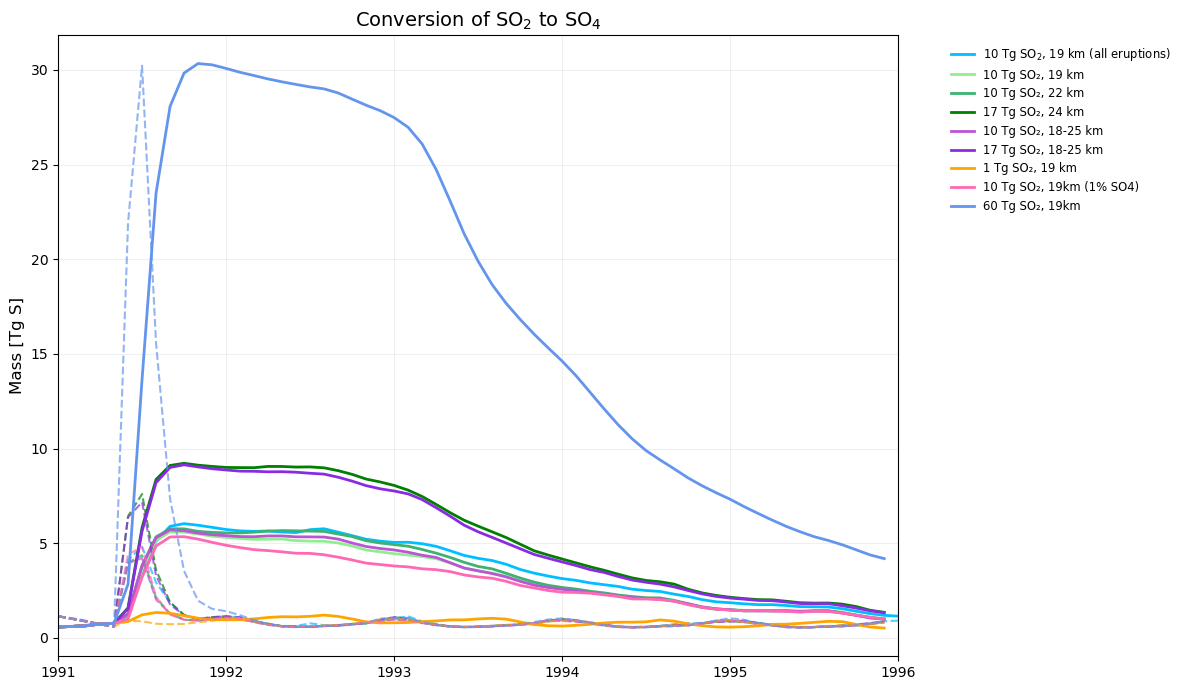

In [91]:
so2_dss = [so2_19, so2_19_c, so2_22, so2_24, so2_1825, so2_1825_17tg, so2_1tg, so2_1pr, so2_60tg]
so4_dss = [mmr_SULFATE_19, mmr_SULFATE_19_c, mmr_SULFATE_22, mmr_SULFATE_24, mmr_SULFATE_1825, mmr_SULFATE_1825_17tg, mmr_SULFATE_1tg, mmr_SULFATE_1pr, mmr_SULFATE_60tg]
titles = [
    "10 Tg SO$_2$, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km",
    "10 Tg SO₂, 19km (1% SO4)",
    "60 Tg SO₂, 19km"
]

colors = [
    "deepskyblue",    # 10 Tg, 19km (all)
    "lightgreen",     # 10 Tg, 19km
    "mediumseagreen", # 10 Tg, 22km
    "green",          # 17 Tg, 24km
    "mediumorchid",   # 10 Tg, 18-25km
    "blueviolet",     # 17 Tg, 18-25km
    "orange",         # 1 Tg, 19km
    "hotpink",     # 10 Tg, 19km (1%)
    "cornflowerblue"  # 60 Tg, 19km
]

fig, ax = plt.subplots(figsize=(12, 7))

def to_year_float(time_axis):
    return np.array([t.year + (t.month-1)/12 for t in time_axis])

for i in range(len(so2_dss)):
    s2_data = so2_dss[i].sel(time=slice('1991', '1996'))
    s4_data = so4_dss[i].sel(time=slice('1991', '1996'))
    
    s2_ts, s4_ts = get_combined_s_timeseries(s2_data, s4_data)
    
    t_float = to_year_float(s2_data.time.values)
    
    ax.plot(t_float, s2_ts, color=colors[i], linestyle='--', alpha=0.7)
    ax.plot(t_float, s4_ts, color=colors[i], linestyle='-', label=titles[i], linewidth=2)

ax.set_xlim(1991, 1996) 
ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])

ax.set_title("Conversion of SO$_2$ to SO$_4$", fontsize=14)
ax.set_ylabel("Mass [Tg S]", fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [39]:
results = []

for i in range(len(so2_dss)):
    s2_ds = so2_dss[i]
    s4_ds = so4_dss[i]

    if i == 0:
        s2_ds = s2_ds.sel(time=slice("1991", "1996"))
        s4_ds = s4_ds.sel(time=slice("1991", "1996"))

    s2_ts, s4_ts = get_combined_s_timeseries(s2_ds, s4_ds)

    s2_max = float(s2_ts.max())
    idx_max = int(s2_ts.argmax())
    t_start = s2_ts.time[idx_max].values
    threshold = s2_max / np.exp(1)

    after_peak = s2_ts.isel(time=slice(idx_max, None))

    vals = after_peak.values
    times = after_peak.time.values

    days_efold = np.nan

    for j in range(1, len(vals)):
        if vals[j] <= threshold and vals[j-1] > threshold:
            t0 = times[j-1]
            t1 = times[j]
            y0 = vals[j-1]
            y1 = vals[j]

            f = (threshold - y0) / (y1 - y0)
            t_cross = t0 + f * (t1 - t0)

            days_efold = (t_cross - t_start) / np.timedelta64(1, "D")
            break

    idx_s4_peak = int(s4_ts.argmax())
    t_s4_peak = s4_ts.time[idx_s4_peak].values
    diff_peak = t_s4_peak - t_start
    
    if hasattr(diff_peak, 'total_seconds'):
        days_to_peak = int(diff_peak.total_seconds() / 86400)
    else:
        days_to_peak = int(diff_peak / np.timedelta64(1, 'D'))

    results.append({
        "Eksperiment": titles[i],
        "Max SO2 (Tg S)": round(s2_max, 2),
        "e-folding (dager)": days_efold,
        "Dager til SO4 peak": days_to_peak
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

                        Eksperiment  Max SO2 (Tg S)  e-folding (dager)  Dager til SO4 peak
10 Tg SO$_2$, 19 km (all eruptions)            4.81          65.894285                  92
                   10 Tg SO₂, 19 km            4.32          49.333891                  62
                   10 Tg SO₂, 22 km            4.37          50.161657                  62
                   17 Tg SO₂, 24 km            7.59          45.341089                  92
                10 Tg SO₂, 18-25 km            4.20          50.433600                  62
                17 Tg SO₂, 18-25 km            7.16          44.331395                  92
                    1 Tg SO₂, 19 km            1.14                NaN                 212
           10 Tg SO₂, 19km (1% SO4)            4.80          44.064124                  92
                    60 Tg SO₂, 19km           30.23          47.793194                 123


<Figure size 700x500 with 0 Axes>

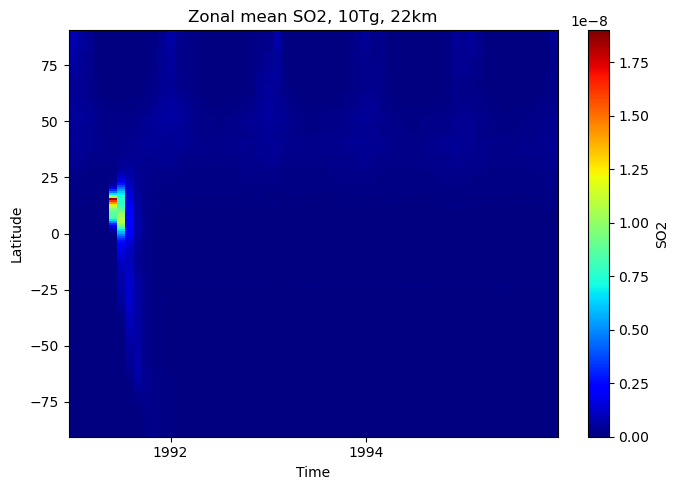

In [40]:
so2 = so2_22["SO2"].weighted(weighted_lat_22).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 22km")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

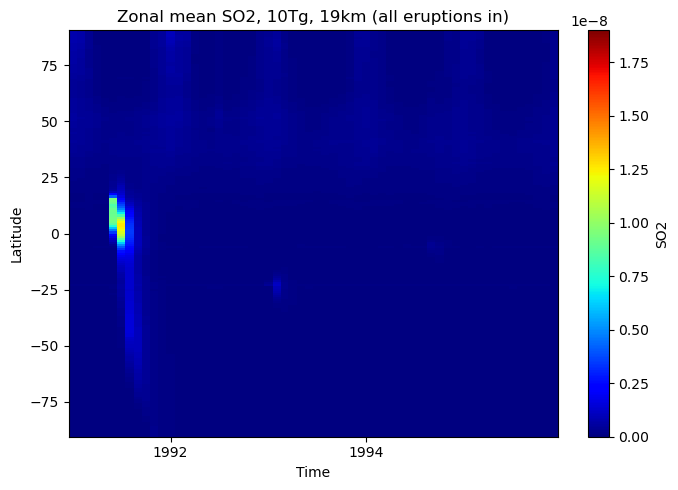

In [41]:
so2 = so2_19["SO2"].weighted(weighted_lat).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 19km (all eruptions in)")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

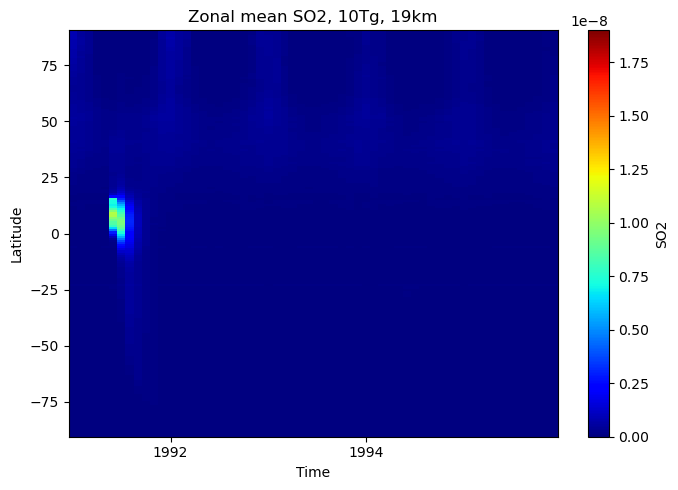

In [42]:
so2 = so2_19_c["SO2"].weighted(weighted_lat_19_c).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 19km")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

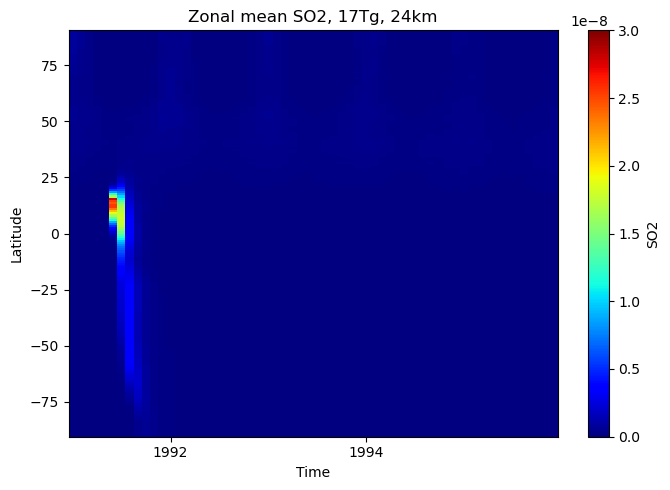

In [43]:
so2 = so2_24["SO2"].weighted(weighted_lat_24).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 3e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 17Tg, 24km")
plt.tight_layout()
plt.show()

### AOD

In [44]:
aod_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/AOD_VIS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in aod_19['time'].values])
aod_19 = aod_19.assign_coords(time=shifted_time_19)
aod_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/AOD_VIS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in aod_19_c['time'].values])
aod_19_c = aod_19_c.assign_coords(time=shifted_time_19_c)
aod_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in aod_22['time'].values])
aod_22 = aod_22.assign_coords(time=shifted_time_22)
aod_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in aod_24['time'].values])
aod_24 = aod_24.assign_coords(time=shifted_time_24)
aod_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in aod_1825_17tg['time'].values])
aod_1825_17tg = aod_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
aod_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in aod_1825['time'].values])
aod_1825 = aod_1825.assign_coords(time=shifted_time_1825)
aod_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in aod_1tg['time'].values])
aod_1tg = aod_1tg.assign_coords(time=shifted_time_1tg)
aod_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/AOD_VIS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in aod_1pr['time'].values])
aod_1pr = aod_1pr.assign_coords(time=shifted_time_1pr)
aod_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/AOD_VIS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in aod_60tg['time'].values])
aod_60tg = aod_60tg.assign_coords(time=shifted_time_60tg)

In [45]:
glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)

/tmp/ipykernel_2927493/2537514140.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_2927493/2537514140.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)


In [46]:
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_saod.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_saod.columns = dates_glossac

months_avhrr = [int(c) for c in avhrr_saod.columns] 
dates_avhrr = [start + pd.DateOffset(months=m) for m in months_avhrr]
avhrr_saod.columns = dates_avhrr

In [47]:
avhrr_global = avhrr_saod.loc["Global_mean"].astype(float)
glossac_global = glossac_saod.loc["Global_mean"].astype(float)

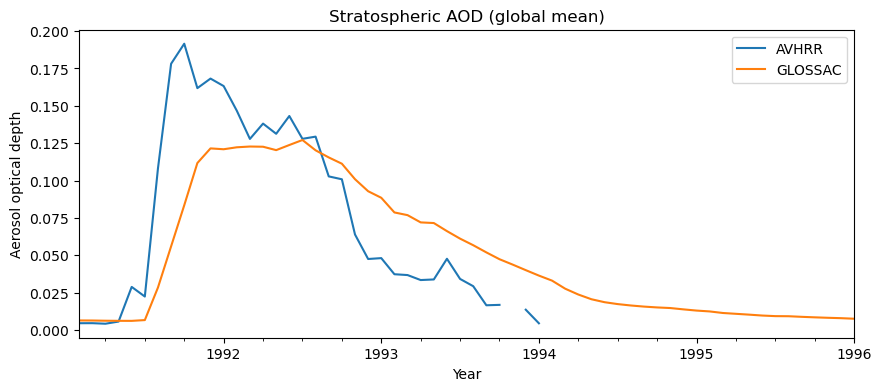

In [48]:
plt.figure(figsize=(10, 4))
avhrr_global.plot(label = "AVHRR")
glossac_global.plot(label="GLOSSAC")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

In [49]:
day_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/DAYFOC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in day_19['time'].values])
day_19 = day_19.assign_coords(time=shifted_time_19)
day_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/DAYFOC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in day_19_c['time'].values])
day_19_c = day_19_c.assign_coords(time=shifted_time_19_c)
day_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/DAYFOC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in day_22['time'].values])
day_22 = day_22.assign_coords(time=shifted_time_22)
day_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/DAYFOC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in day_24['time'].values])
day_24 = day_24.assign_coords(time=shifted_time_24)
day_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in day_1825_17tg['time'].values])
day_1825_17tg = day_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
day_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in day_1825['time'].values])
day_1825 = day_1825.assign_coords(time=shifted_time_1825)
day_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in day_1tg['time'].values])
day_1tg = day_1tg.assign_coords(time=shifted_time_1tg)
day_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/DAYFOC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in day_1pr['time'].values])
day_1pr = day_1pr.assign_coords(time=shifted_time_1pr)
day_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/DAYFOC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in day_60tg['time'].values])
day_60tg = day_60tg.assign_coords(time=shifted_time_60tg)

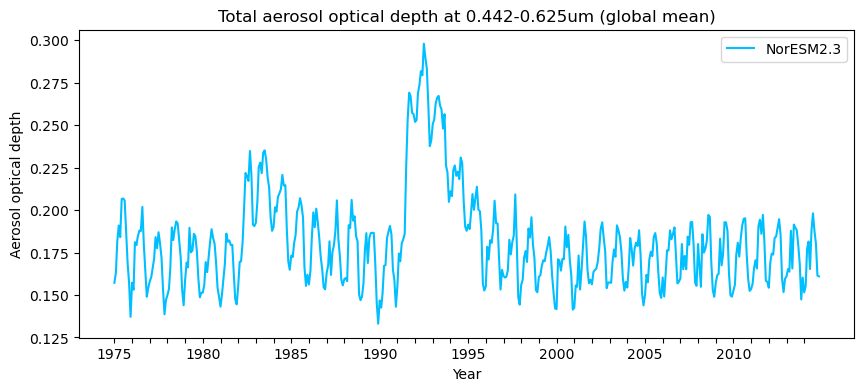

In [50]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = aod_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = day_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()
ts_aod_22 = aod_22[aod500].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = day_22[daylight].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22 = ts_aod_22 / daylight_monthly_22
ts_aod_19_c = aod_19_c[aod500].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = day_19_c[daylight].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c = ts_aod_19_c / daylight_monthly_19_c
ts_aod_24 = aod_24[aod500].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24= day_24[daylight].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24 = ts_aod_24 / daylight_monthly_24
ts_aod_1825 =aod_1825[aod500].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825= day_1825[daylight].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825 = ts_aod_1825 / daylight_monthly_1825
ts_aod_1825_17tg = aod_1825_17tg[aod500].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg= day_1825_17tg[daylight].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg = ts_aod_1825_17tg / daylight_monthly_1825_17tg
ts_aod_1tg = aod_1tg[aod500].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg= day_1tg[daylight].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg = ts_aod_1tg / daylight_monthly_1tg
ts_aod_1pr = aod_1pr[aod500].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr= day_1pr[daylight].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr = ts_aod_1pr / daylight_monthly_1pr
ts_aod_60tg = aod_60tg[aod500].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg= day_60tg[daylight].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg = ts_aod_60tg / daylight_monthly_60tg

plt.figure(figsize=(10, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()


In [51]:
aod_trop = aod_19[aod500].sel(lat=slice(-20,20))
ts_aod_trop = aod_trop.weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_trop = day_19[daylight].sel(lat=slice(-20,20))
daylight_monthly_trop = daylight_trop.weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod_trop = ts_aod_trop / daylight_monthly_trop

aod_19_c_trop = aod_19_c[aod500].sel(lat=slice(-20,20))
ts_aod_19_c_trop = aod_19_c_trop.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_19_c_trop = day_19_c[daylight].sel(lat=slice(-20,20))
daylight_monthly_19_c_trop = daylight_19_c_trop.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c_trop = ts_aod_19_c_trop / daylight_monthly_19_c_trop

aod_22_trop = aod_22[aod500].sel(lat=slice(-20,20))
ts_aod_22_trop = aod_22_trop.weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_22_trop = day_22[daylight].sel(lat=slice(-20,20))
daylight_monthly_22_trop = daylight_22_trop.weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22_trop = ts_aod_22_trop / daylight_monthly_22_trop

aod_24_trop = aod_24[aod500].sel(lat=slice(-20,20))
ts_aod_24_trop = aod_24_trop.weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_24_trop = day_24[daylight].sel(lat=slice(-20,20))
daylight_monthly_24_trop = daylight_24_trop.weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24_trop = ts_aod_24_trop / daylight_monthly_24_trop

aod_1825_trop = aod_1825[aod500].sel(lat=slice(-20,20))
ts_aod_1825_trop = aod_1825_trop.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_1825_trop = day_1825[daylight].sel(lat=slice(-20,20))
daylight_monthly_1825_trop = daylight_1825_trop.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825_trop = ts_aod_1825_trop / daylight_monthly_1825_trop

aod_1825_17tg_trop = aod_1825_17tg[aod500].sel(lat=slice(-20,20))
ts_aod_1825_17tg_trop = aod_1825_17tg_trop.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_1825_17tg_trop = day_1825_17tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_1825_17tg_trop = daylight_1825_17tg_trop.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg_trop = ts_aod_1825_17tg_trop / daylight_monthly_1825_17tg_trop

aod_1tg_trop = aod_1tg[aod500].sel(lat=slice(-20,20))
ts_aod_1tg_trop = aod_1tg_trop.weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_1tg_trop = day_1tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_1tg_trop = daylight_1tg_trop.weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg_trop = ts_aod_1tg_trop / daylight_monthly_1tg_trop

aod_1pr_trop = aod_1pr[aod500].sel(lat=slice(-20,20))
ts_aod_1pr_trop = aod_1pr_trop.weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_1pr_trop = day_1pr[daylight].sel(lat=slice(-20,20))
daylight_monthly_1pr_trop = daylight_1pr_trop.weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr_trop = ts_aod_1pr_trop / daylight_monthly_1pr_trop

aod_60tg_trop = aod_60tg[aod500].sel(lat=slice(-20,20))
ts_aod_60tg_trop = aod_60tg_trop.weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_60tg_trop = day_60tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_60tg_trop = daylight_60tg_trop.weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg_trop = ts_aod_60tg_trop / daylight_monthly_60tg_trop

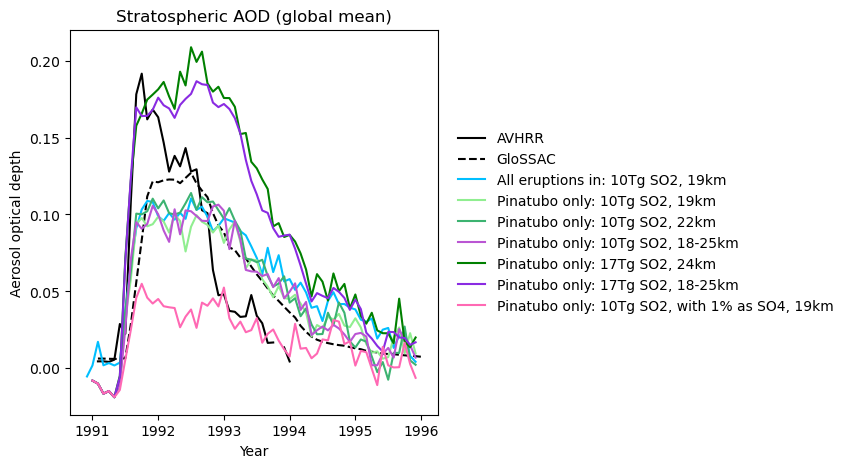

In [52]:
pre_eruption = ts_aod.sel(time=slice("1976-01", "1981-12"))
base = pre_eruption.groupby("time.month").mean("time")
aod_anom = ts_aod.groupby("time.month") - base
aod_anom_22 = ts_aod_22.groupby("time.month") - base
aod_anom_19_c = ts_aod_19_c.groupby("time.month") - base
aod_anom_24 = ts_aod_24.groupby("time.month") - base
aod_anom_1825 = ts_aod_1825.groupby("time.month") - base
aod_anom_1825_17tg = ts_aod_1825_17tg.groupby("time.month") - base
aod_anom_1tg = ts_aod_1tg.groupby("time.month") - base
aod_anom_1pr = ts_aod_1pr.groupby("time.month") - base
aod_anom_60tg = ts_aod_60tg.groupby("time.month") - base
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))
aod_smooth = aod_Pinatubo.rolling(time=1, center=True).mean()

obs_time_avhrr = np.array([t.year + (t.month-1)/12 for t in avhrr_global.index])
obs_time_glossac = np.array([t.year + (t.month-1)/12 for t in glossac_global.index])
time_years = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo.time.values])
time_years_22 = np.array([t.year + (t.month-1)/12 for t in aod_anom_22.time.values])
time_years_19_c = np.array([t.year + (t.month-1)/12 for t in aod_anom_19_c.time.values])
time_years_24 = np.array([t.year + (t.month-1)/12 for t in aod_anom_24.time.values])
time_years_1825 = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825.time.values])
time_years_1825_17tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_17tg.time.values])
time_years_1tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_1tg.time.values])
time_years_1pr = np.array([t.year + (t.month-1)/12 for t in aod_anom_1pr.time.values])
time_years_60tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_60tg.time.values])

plt.figure(figsize=(7, 5))
plt.plot(obs_time_avhrr, avhrr_global, color = "black", label = "AVHRR")
plt.plot(obs_time_glossac, glossac_global, color = "black", linestyle="--", label = "GloSSAC")
plt.plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(time_years_22, aod_anom_22, color = "mediumseagreen", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(time_years_1825, aod_anom_1825, color = "mediumorchid", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.plot(time_years_24, aod_anom_24, color = "green", label = "Pinatubo only: 17Tg SO2, 24km")
plt.plot(time_years_1825_17tg, aod_anom_1825_17tg, color = "blueviolet", label = "Pinatubo only: 17Tg SO2, 18-25km")
#plt.plot(time_years_1tg, aod_anom_1tg, color = "orange", label = "Pinatubo only: 1Tg SO2, 19km")
plt.plot(time_years_1pr, aod_anom_1pr, color = "hotpink", label = "Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
#plt.plot(time_years_60tg, aod_anom_60tg, color = "cornflowerblue", label = "Pinatubo only: 60Tg SO2, 19km")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
fig = plt.gcf()
ax = plt.gca()

fig.subplots_adjust(right=0.65)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

In [53]:
pre_eruption_trop = ts_aod_trop.sel(time=slice("1976-01", "1981-12"))
base_trop = pre_eruption_trop.groupby("time.month").mean("time")
aod_anom_trop = ts_aod_trop.groupby("time.month") - base_trop
aod_anom_22_trop = ts_aod_22_trop.groupby("time.month") - base_trop
aod_anom_19_c_trop = ts_aod_19_c_trop.groupby("time.month") - base_trop
aod_anom_24_trop = ts_aod_24_trop.groupby("time.month") - base_trop
aod_anom_1825_trop = ts_aod_1825_trop.groupby("time.month") - base_trop
aod_anom_1825_17tg_trop = ts_aod_1825_17tg_trop.groupby("time.month") - base_trop
aod_anom_1tg_trop = ts_aod_1tg_trop.groupby("time.month") - base_trop
aod_anom_1pr_trop = ts_aod_1pr_trop.groupby("time.month") - base_trop
aod_anom_60tg_trop = ts_aod_60tg_trop.groupby("time.month") - base_trop
aod_Pinatubo_trop = aod_anom_trop.sel(time=slice("1990-12", "1995-12"))

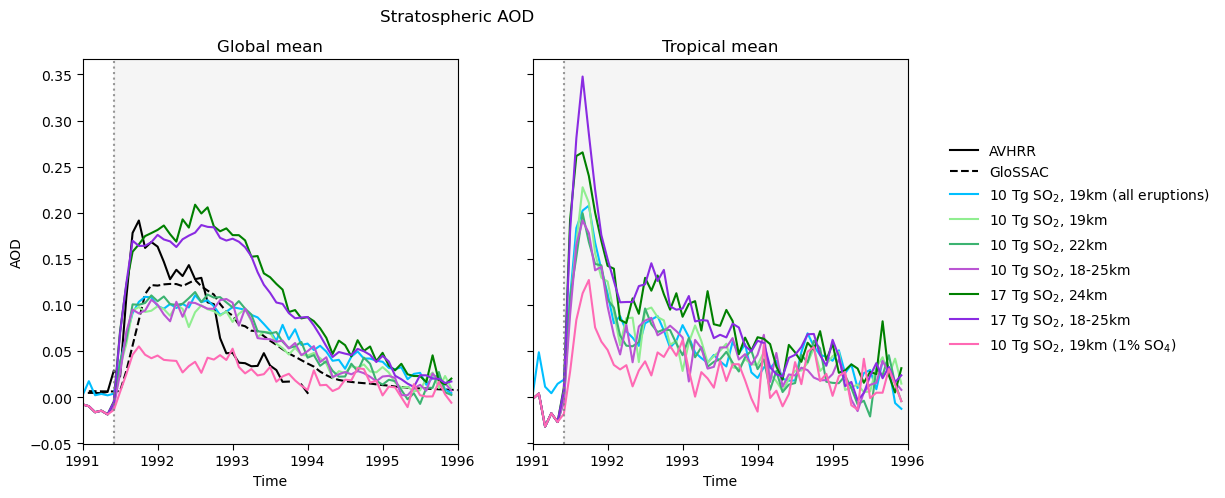

In [54]:
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)
time_years_trop = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo_trop.time.values])
time_years_22_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_22_trop.time.values])
time_years_19_c_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_19_c_trop.time.values])
time_years_24_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_24_trop.time.values])
time_years_1825_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_trop.time.values])
time_years_1825_17tg_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_17tg_trop.time.values])
time_years_1tg_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1tg_trop.time.values])
time_years_1pr_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1pr_trop.time.values])
time_years_60tg_trop= np.array([t.year + (t.month-1)/12 for t in aod_anom_60tg_trop.time.values])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(obs_time_avhrr, avhrr_global, color = "black", label = "AVHRR")
ax[0].plot(obs_time_glossac, glossac_global, color = "black", linestyle="--", label = "GloSSAC")
ax[0].plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[0].plot(time_years_22, aod_anom_22, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[0].plot(time_years_1825, aod_anom_1825, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[0].plot(time_years_24, aod_anom_24, color = "green", label = "17 Tg SO$_2$, 24km")
ax[0].plot(time_years_1825_17tg, aod_anom_1825_17tg, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[0].plot(aod_anom_1tg.time, aod_anom_1tg, color="orange", label="1 Tg SO2, 19km")
ax[0].plot(time_years_1pr, aod_anom_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(aod_anom_60tg.time, aod_anom_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[0].set_ylabel("AOD")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

ax[1].plot(time_years_trop, aod_Pinatubo_trop, color = "deepskyblue", label = "10 Tg, 19 km (all eruptions)")
ax[1].plot(time_years_19_c_trop, aod_anom_19_c_trop, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[1].plot(time_years_22_trop, aod_anom_22_trop, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[1].plot(time_years_1825_trop, aod_anom_1825_trop, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[1].plot(time_years_24_trop, aod_anom_24_trop, color = "green", label = "17 Tg SO$_2$, 24km")
ax[1].plot(time_years_1825_17tg_trop, aod_anom_1825_17tg_trop, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[1].plot(aod_anom_1tg_trop.time, aod_anom_1tg_trop, color="orange", label="1 Tg SO2, 19km")
ax[1].plot(time_years_1pr_trop, aod_anom_1pr_trop, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(aod_anom_60tg_trop.time, aod_anom_60tg_trop, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.set_xlim(1991, 1996) 
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.tick_params(direction='out', length=4)
    

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric AOD")
fig.subplots_adjust(right=0.95)
plt.show()

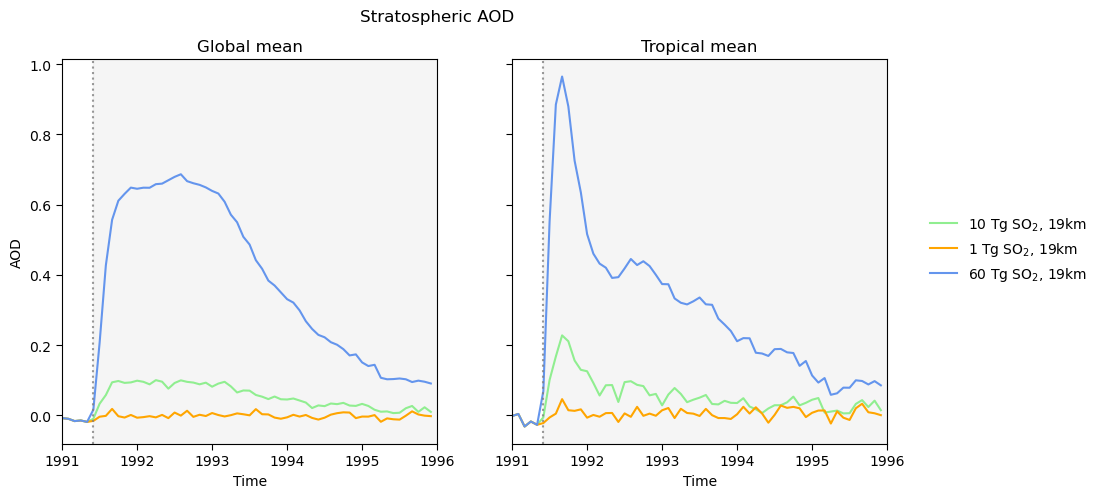

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
#ax[0].plot(aod_Pinatubo.time, aod_Pinatubo, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[0].plot(time_years_1tg, aod_anom_1tg, color="orange", label="1 Tg SO$_2$, 19km")
ax[0].plot(time_years_60tg, aod_anom_60tg, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[0].set_ylabel("AOD")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

#ax[1].plot(aod_Pinatubo_trop.time, aod_Pinatubo_trop, color = "deepskyblue", label = "10 Tg, 19 km (all eruptions)")
ax[1].plot(time_years_19_c_trop, aod_anom_19_c_trop, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[1].plot(time_years_1tg_trop, aod_anom_1tg_trop, color="orange", label="1 Tg SO$_2$, 19km")
ax[1].plot(time_years_60tg_trop, aod_anom_60tg_trop, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.set_xlim(1991, 1996) 
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.tick_params(direction='out', length=4)
    

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric AOD")
fig.subplots_adjust(right=0.95)
plt.show()

In [56]:
aod_19 = aod_19[aod500]
daylight_monthly_nw_19 = day_19[daylight]
aod_19 = aod_19 / daylight_monthly_nw_19

baseline = aod_19.sel(time=slice("1976-01", "1981-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat_19 = aod_19.groupby("time.month") - base

aod_zoom_19 = aod_strat_19.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_19 = aod_zoom_19['time'].values
aod_lat_time_19 = aod_zoom_19.mean(dim="lon")
lat_19 = aod_lat_time_19["lat"]


In [57]:
aod_22 = aod_22[aod500]
daylight_monthly_nw_22 = day_22[daylight]
aod_22 = aod_22 / daylight_monthly_nw_22
aod_strat_22 = aod_22.groupby("time.month") - base

aod_zoom_22 = aod_strat_22.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_22 = aod_zoom_22['time'].values
aod_lat_time_22 = aod_zoom_22.mean(dim="lon")
lat_22 = aod_lat_time_22["lat"]

In [58]:
aod_19_c = aod_19_c[aod500]
daylight_monthly_nw_19_c = day_19_c[daylight]
aod_19_c = aod_19_c / daylight_monthly_nw_19_c
aod_strat_19_c = aod_19_c.groupby("time.month") - base

aod_zoom_19_c = aod_strat_19_c.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_19_c = aod_zoom_19_c['time'].values
aod_lat_time_19_c = aod_zoom_19_c.mean(dim="lon")
lat_19_c = aod_lat_time_19_c["lat"]

In [59]:
aod_24 = aod_24[aod500]
daylight_monthly_nw_24 = day_24[daylight]
aod_24 = aod_24 / daylight_monthly_nw_24
aod_strat_24= aod_24.groupby("time.month") - base

aod_zoom_24 = aod_strat_24.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_24 = aod_zoom_24['time'].values
aod_lat_time_24 = aod_zoom_24.mean(dim="lon")
lat_24 = aod_lat_time_24["lat"]

In [60]:
aod_1825 = aod_1825[aod500]
daylight_monthly_nw_1825 = day_1825[daylight]
aod_1825 = aod_1825 / daylight_monthly_nw_1825
aod_strat_1825= aod_1825.groupby("time.month") - base

aod_zoom_1825 = aod_strat_1825.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1825 = aod_zoom_1825['time'].values
aod_lat_time_1825 = aod_zoom_1825.mean(dim="lon")
lat_1825 = aod_lat_time_1825["lat"]

In [61]:
aod_1825_17tg = aod_1825_17tg[aod500]
daylight_monthly_nw_1825_17tg = day_1825_17tg[daylight]
aod_1825_17tg = aod_1825_17tg / daylight_monthly_nw_1825_17tg
aod_strat_1825_17tg= aod_1825_17tg.groupby("time.month") - base

aod_zoom_1825_17tg = aod_strat_1825_17tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1825_17tg = aod_zoom_1825_17tg['time'].values
aod_lat_time_1825_17tg = aod_zoom_1825_17tg.mean(dim="lon")
lat_1825_17tg = aod_lat_time_1825_17tg["lat"]

In [62]:
aod_1tg = aod_1tg[aod500]
daylight_monthly_nw_1tg = day_1tg[daylight]
aod_1tg = aod_1tg / daylight_monthly_nw_1tg
aod_strat_1tg= aod_1tg.groupby("time.month") - base

aod_zoom_1tg = aod_strat_1tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1tg = aod_zoom_1tg['time'].values
aod_lat_time_1tg = aod_zoom_1tg.mean(dim="lon")
lat_1tg = aod_lat_time_1tg["lat"]

In [63]:
aod_1pr = aod_1pr[aod500]
daylight_monthly_nw_1pr = day_1pr[daylight]
aod_1pr = aod_1pr/ daylight_monthly_nw_1pr
aod_strat_1pr= aod_1pr.groupby("time.month") - base

aod_zoom_1pr = aod_strat_1pr.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1pr = aod_zoom_1pr['time'].values
aod_lat_time_1pr = aod_zoom_1pr.mean(dim="lon")
lat_1pr = aod_lat_time_1pr["lat"]

In [64]:
aod_60tg = aod_60tg[aod500]
daylight_monthly_nw_60tg = day_60tg[daylight]
aod_60tg = aod_60tg/ daylight_monthly_nw_60tg
aod_strat_60tg= aod_60tg.groupby("time.month") - base

aod_zoom_60tg = aod_strat_60tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_60tg = aod_zoom_60tg['time'].values
aod_lat_time_60tg = aod_zoom_60tg.mean(dim="lon")
lat_60tg = aod_lat_time_60tg["lat"]

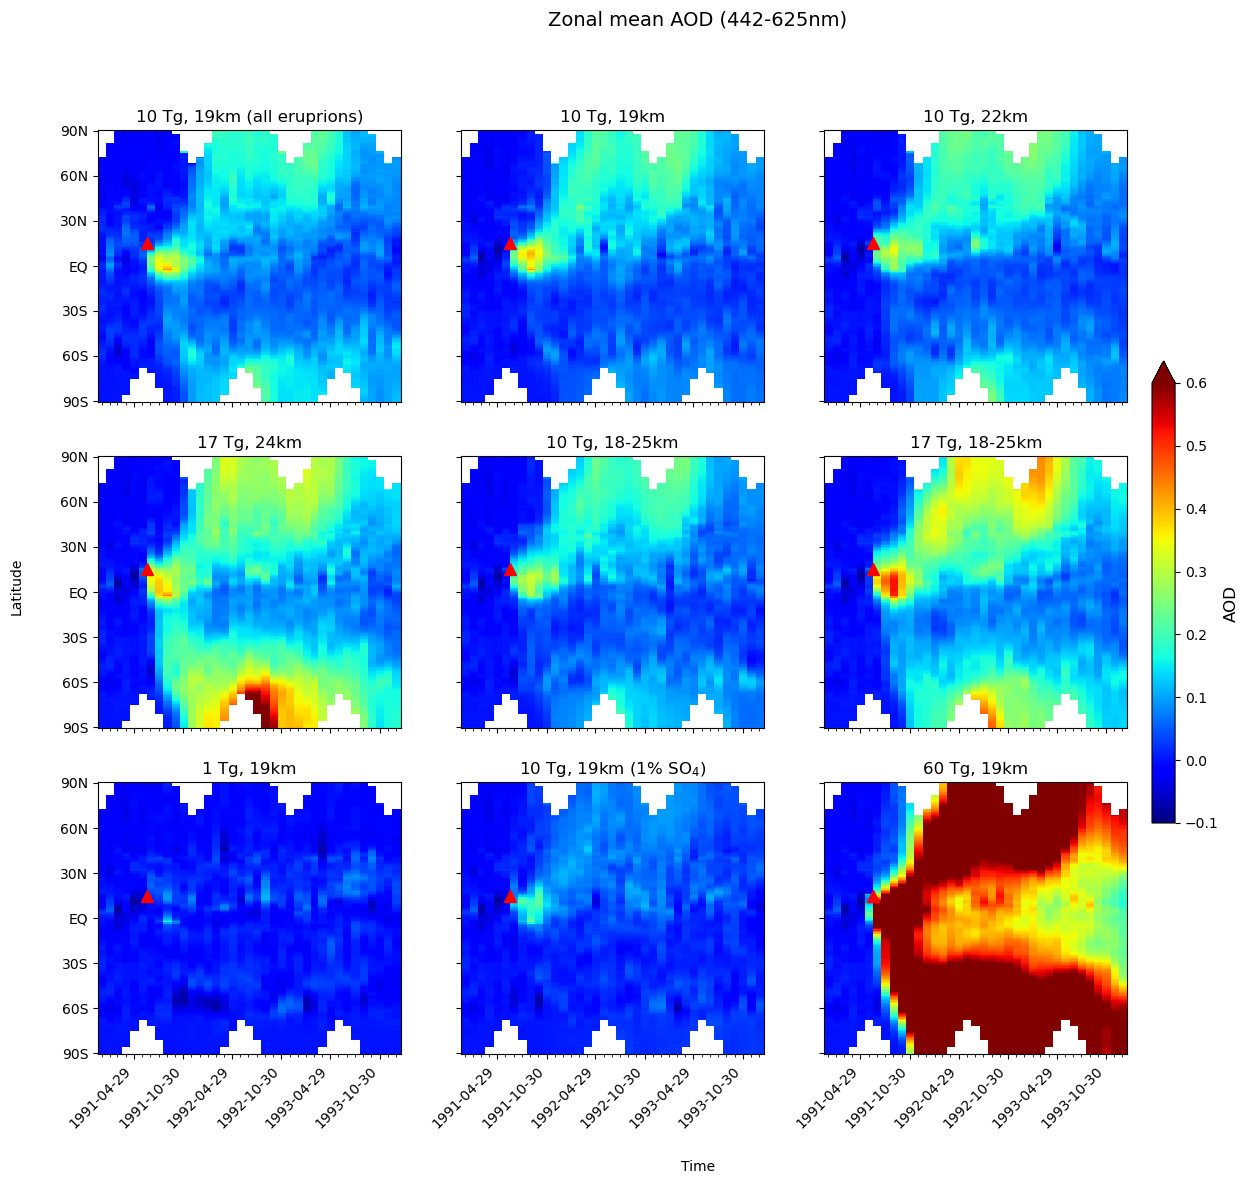

In [65]:
all_aod_lat = [aod_lat_time_19, aod_lat_time_19_c, aod_lat_time_22, aod_lat_time_24, aod_lat_time_1825, 
           aod_lat_time_1825_17tg, aod_lat_time_1tg, aod_lat_time_1pr, aod_lat_time_60tg]

all_times = [time_zoom_19, time_zoom_19_c, time_zoom_22, time_zoom_24, time_zoom_1825, 
             time_zoom_1825_17tg, time_zoom_1tg, time_zoom_1pr, time_zoom_60tg]

all_lat = [lat_19, lat_19_c, lat_22, lat_24, lat_1825, 
             lat_1825_17tg, lat_1tg, lat_1pr, lat_60tg]

titles = ["10 Tg, 19km (all eruprions)", "10 Tg, 19km", "10 Tg, 22km", "17 Tg, 24km", 
          "10 Tg, 18-25km", "17 Tg, 18-25km", "1 Tg, 19km", 
          "10 Tg, 19km (1% SO$_4$)", "60 Tg, 19km"]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, ax in enumerate(axs.flat):
    if i < len(all_aod_lat):
        pc = ax.pcolormesh(all_times[i], all_lat[i], all_aod_lat[i].T, 
                         vmax = 0.6, vmin = -0.1, shading="auto", cmap="jet")
        
        ax.plot(
            cftime.DatetimeNoLeap(1991, 6, 15),
            15,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )
        
        ax.set_title(titles[i], fontsize=12)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

if pc:
    cbar = fig.colorbar(pc, ax=axs, location='right', shrink=0.5, pad=0.02, extend='max')
    cbar.set_label("AOD", fontsize=12)

for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)
fig.suptitle("Zonal mean AOD (442-625nm)", fontsize=14)

plt.tight_layout
plt.show()


## Ozone

In [66]:
cb_O3_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/cb_O3_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in cb_O3_19['time'].values])
cb_O3_19 = cb_O3_19.assign_coords(time=shifted_time_19)
cb_O3_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/cb_O3_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in cb_O3_19_c['time'].values])
cb_O3_19_c = cb_O3_19_c.assign_coords(time=shifted_time_19_c)
cb_O3_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/cb_O3_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in cb_O3_22['time'].values])
cb_O3_22 = cb_O3_22.assign_coords(time=shifted_time_22)
cb_O3_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/cb_O3_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in cb_O3_24['time'].values])
cb_O3_24 = cb_O3_24.assign_coords(time=shifted_time_24)
cb_O3_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in cb_O3_1825_17tg['time'].values])
cb_O3_1825_17tg = cb_O3_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
cb_O3_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in cb_O3_1825['time'].values])
cb_O3_1825 = cb_O3_1825.assign_coords(time=shifted_time_1825)
cb_O3_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/cb_O3_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in cb_O3_1tg['time'].values])
cb_O3_1tg = cb_O3_1tg.assign_coords(time=shifted_time_1tg)
cb_O3_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/cb_O3_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in cb_O3_1pr['time'].values])
cb_O3_1pr = cb_O3_1pr.assign_coords(time=shifted_time_1pr)
cb_O3_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/cb_O3_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in cb_O3_60tg['time'].values])
cb_O3_60tg = cb_O3_60tg.assign_coords(time=shifted_time_60tg)

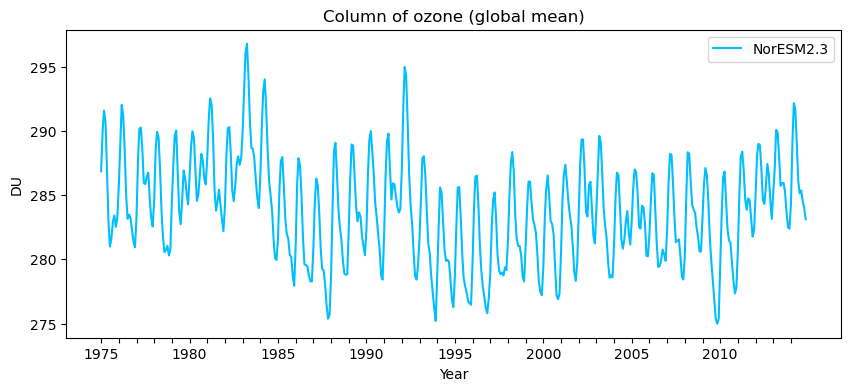

In [67]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = cb_O3_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(10, 4))
o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("Column of ozone (global mean)")
plt.legend()
plt.show()

In [68]:
def calc_anomaly(ds, weights, baseline_obj, lat_range=None):
    var = "cb_O3" 
    
    if lat_range:
        data = ds[var].sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = ds[var]
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"]) * DU
    anom = mean_ts.groupby("time.month") - baseline_obj
    return anom.sel(time=slice('1991-01-01', '1996-01-01'))

In [69]:
# Global
o3_glob = cb_O3_19["cb_O3"].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
base_global = o3_glob.sel(time=slice("1975", "1990")).groupby("time.month").mean()

# Tropics
o3_trop = cb_O3_19["cb_O3"].sel(lat=slice(-20,20)).weighted(weighted_lat.sel(lat=slice(-20,20))).mean(dim=["lat", "lon"]) * DU
base_trop = o3_trop.sel(time=slice("1975", "1990")).groupby("time.month").mean()

In [70]:
o3_anom = calc_anomaly(cb_O3_19, weighted_lat, base_global)
o3_19_c_anom = calc_anomaly(cb_O3_19_c, weighted_lat_19_c, base_global)
o3_22_anom = calc_anomaly(cb_O3_22, weighted_lat_22, base_global)
o3_24_anom = calc_anomaly(cb_O3_24, weighted_lat_24, base_global)
o3_1825_anom = calc_anomaly(cb_O3_1825, weighted_lat_1825, base_global)
o3_1825_17tg_anom = calc_anomaly(cb_O3_1825_17tg, weighted_lat_1825_17tg, base_global)
o3_1pr_anom = calc_anomaly(cb_O3_1pr, weighted_lat_1pr, base_global)
o3_1tg_anom = calc_anomaly(cb_O3_1tg, weighted_lat_1tg, base_global)
o3_60tg_anom = calc_anomaly(cb_O3_60tg, weighted_lat_60tg, base_global)

In [71]:
o3_anom_trop = calc_anomaly(cb_O3_19, weighted_lat, base_trop, lat_range=(-20,20))
o3_19_c_anom_trop = calc_anomaly(cb_O3_19_c, weighted_lat_19_c, base_trop, lat_range=(-20,20))
o3_22_anom_trop = calc_anomaly(cb_O3_22, weighted_lat_22, base_trop, lat_range=(-20,20))
o3_24_anom_trop = calc_anomaly(cb_O3_24, weighted_lat_24, base_trop, lat_range=(-20,20))
o3_1825_anom_trop = calc_anomaly(cb_O3_1825, weighted_lat_1825, base_trop, lat_range=(-20,20))
o3_1825_17tg_anom_trop = calc_anomaly(cb_O3_1825_17tg, weighted_lat_1825_17tg, base_trop, lat_range=(-20,20))
o3_1pr_anom_trop = calc_anomaly(cb_O3_1pr, weighted_lat_1pr, base_trop, lat_range=(-20,20))
o3_1tg_anom_trop = calc_anomaly(cb_O3_1tg, weighted_lat_1tg, base_trop, lat_range=(-20,20))
o3_60tg_anom_trop = calc_anomaly(cb_O3_60tg, weighted_lat_60tg, base_trop, lat_range=(-20,20))

In [72]:
o3_anom

<xarray.DataArray 'cb_O3' (time: 61)> Size: 488B
array([-2.22108825, -1.3054962 , -1.03711806, -0.41160858, -0.78894616,
       -0.11383968,  2.58202325,  2.35183509,  1.40501767,  1.45288972,
        2.08822805,  2.58350601,  2.78622309,  3.97883925,  4.74861659,
        4.06184866,  2.93779194,  1.80167846,  0.92678196, -0.70721444,
       -2.90693744, -3.94396158, -3.13036859, -1.84816231, -2.49832906,
       -3.16229472, -2.35803867, -2.17746171, -1.23928566, -1.09083391,
       -2.09589105, -3.03459429, -4.88164592, -5.17541979, -5.37694129,
       -6.11764389, -5.5442883 , -5.34524974, -4.62788568, -4.9962035 ,
       -4.80404007, -4.01525044, -3.45682215, -3.53394221, -3.69749934,
       -4.1850551 , -4.6835065 , -5.03962239, -5.45138551, -5.29258425,
       -4.63695987, -4.56601229, -4.44514501, -4.31872895, -4.77729794,
       -5.58468014, -6.09477063, -5.90008215, -4.97258595, -4.85347836,
       -4.40156738])
Coordinates:
  * time     (time) object 488B 1991-01-01 00:00:00 ... 1996-01-01 00:00:00
    month    (time) int64 488B 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12 1

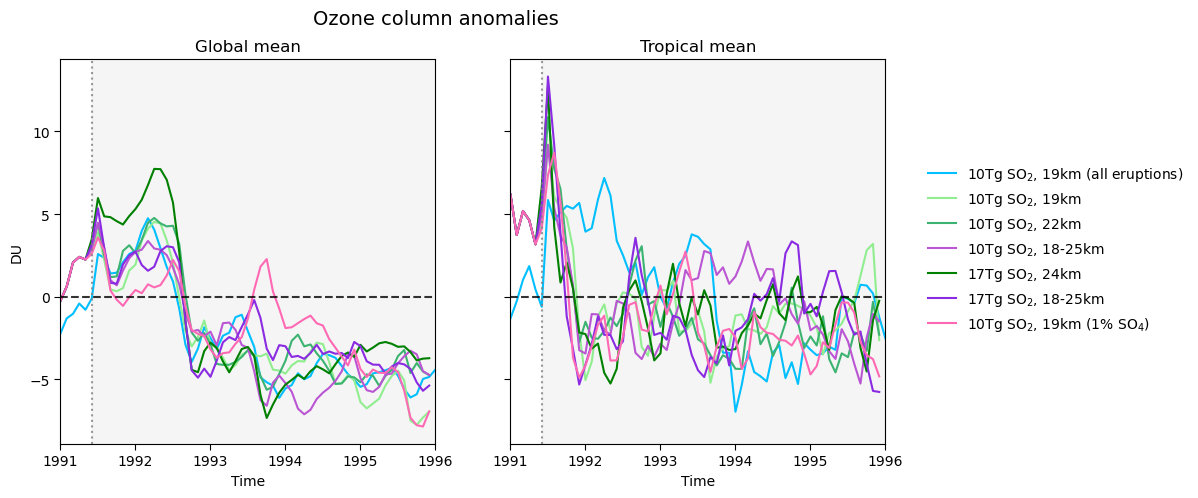

In [73]:
t_19     = [t.year + (t.month-1)/12 for t in o3_anom.time.values]
t_19_c   = [t.year + (t.month-1)/12 for t in o3_19_c_anom.time.values]
t_22     = [t.year + (t.month-1)/12 for t in o3_22_anom.time.values]
t_1825   = [t.year + (t.month-1)/12 for t in o3_1825_anom.time.values]
t_24     = [t.year + (t.month-1)/12 for t in o3_24_anom.time.values]
t_1825_17tg   = [t.year + (t.month-1)/12 for t in o3_1825_17tg_anom.time.values]
t_1tg    = [t.year + (t.month-1)/12 for t in o3_1tg_anom.time.values]
t_1pr    = [t.year + (t.month-1)/12 for t in o3_1pr_anom.time.values]
t_60tg   = [t.year + (t.month-1)/12 for t in o3_60tg_anom.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t_19, o3_anom, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_22, o3_22_anom, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[0].plot(t_1825, o3_1825_anom, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[0].plot(t_24, o3_24_anom, color = "green", label = "17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg, o3_1825_17tg_anom, color = "blueviolet", label = "17Tg SO$_2$, 18-25km")
#ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_1pr, o3_1pr_anom, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(t_19, o3_anom_trop, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_22, o3_22_anom_trop, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[1].plot(t_1825, o3_1825_anom_trop, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[1].plot(t_24, o3_24_anom_trop, color = "green", label = "17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg, o3_1825_17tg_anom_trop, color = "blueviolet", label =  "17Tg SO$_2$, 18-25km")
#ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_1pr, o3_1pr_anom_trop, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

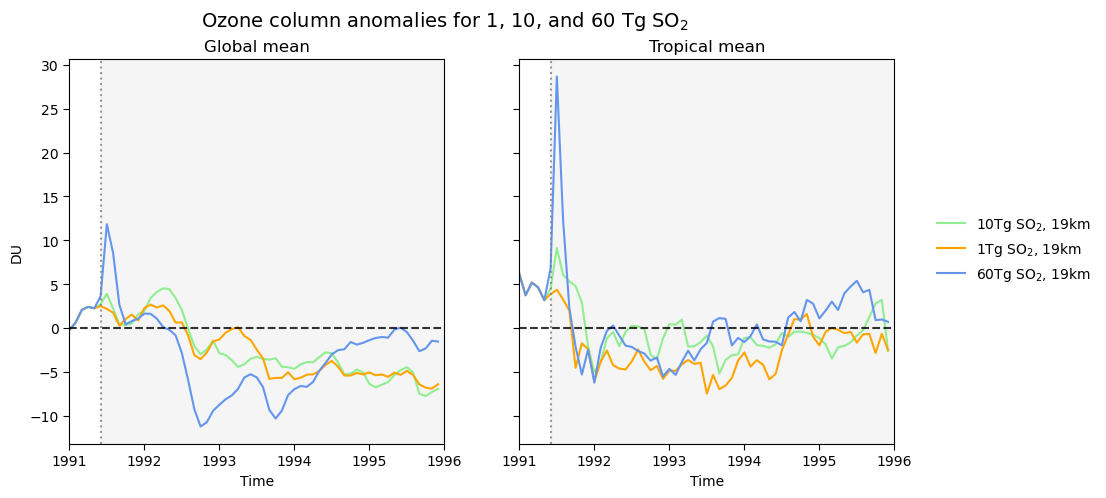

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies for 1, 10, and 60 Tg SO$_2$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [75]:
def get_total_du(ds, lat_range=None):
    var = "cb_O3"
    data = ds[var].sel(lat=slice(*lat_range)) if lat_range else ds[var]
    weights = np.cos(np.deg2rad(data.lat))
    return data.weighted(weights).mean(dim=["lat", "lon"]) * DU

o3 = get_total_du(cb_O3_19)
o3_19_c = get_total_du(cb_O3_19_c)
o3_22 = get_total_du(cb_O3_22)
o3_1825 = get_total_du(cb_O3_1825)
o3_24 = get_total_du(cb_O3_24)
o3_1825_17tg = get_total_du(cb_O3_1825_17tg)
o3_1pr = get_total_du(cb_O3_1pr)
o3_1tg = get_total_du(cb_O3_1tg)
o3_60tg = get_total_du(cb_O3_60tg)

o3_trop = get_total_du(cb_O3_19, lat_range=(-20, 20))
o3_19_c_trop = get_total_du(cb_O3_19_c, lat_range=(-20, 20))
o3_22_trop = get_total_du(cb_O3_22, lat_range=(-20, 20))
o3_1825_trop = get_total_du(cb_O3_1825, lat_range=(-20, 20))
o3_24_trop = get_total_du(cb_O3_24, lat_range=(-20, 20))
o3_1825_17tg_trop = get_total_du(cb_O3_1825_17tg, lat_range=(-20, 20))
o3_1pr_trop = get_total_du(cb_O3_1pr, lat_range=(-20, 20))
o3_1tg_trop = get_total_du(cb_O3_1tg, lat_range=(-20,20))
o3_60tg_trop = get_total_du(cb_O3_60tg, lat_range=(-20,20))

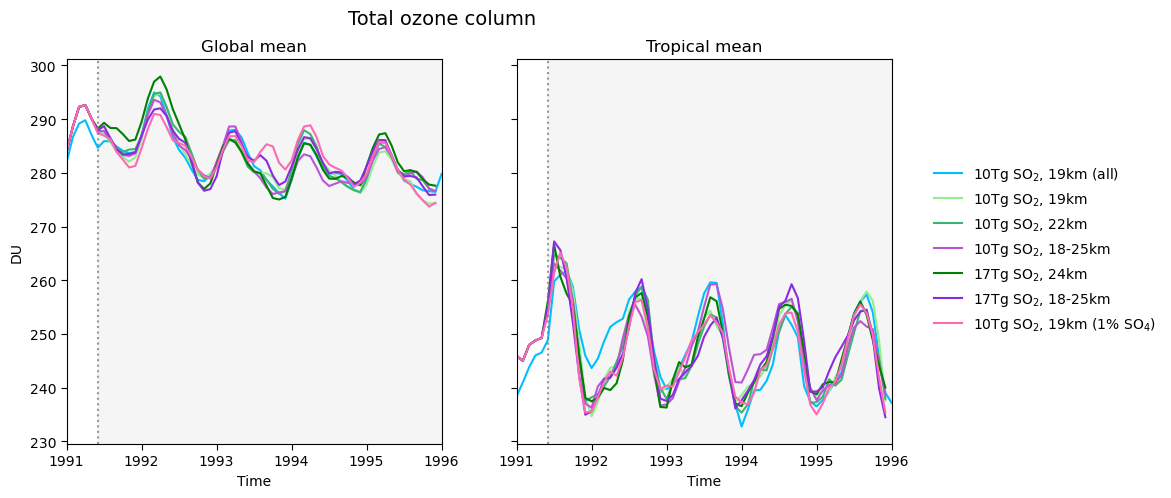

In [76]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
def to_float(x):
    return [t.year + (t.month-1)/12 for t in x.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(o3), o3, color="deepskyblue", label="10Tg SO$_2$, 19km (all)")
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_22), o3_22, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[0].plot(to_float(o3_1825), o3_1825, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[0].plot(to_float(o3_24), o3_24, color="green", label="17Tg SO$_2$, 24km")
ax[0].plot(to_float(o3_1825_17tg), o3_1825_17tg, color="blueviolet", label="17Tg SO$_2$, 18-25km")
#ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1pr), o3_1pr, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_ylabel("DU")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

ax[1].plot(to_float(o3_trop), o3_trop, color="deepskyblue")
ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_22_trop), o3_22_trop, color="mediumseagreen")
ax[1].plot(to_float(o3_1825_trop), o3_1825_trop, color="mediumorchid")
ax[1].plot(to_float(o3_24_trop), o3_24_trop, color="green")
ax[1].plot(to_float(o3_1825_17tg_trop), o3_1825_17tg_trop, color="blueviolet")
#ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_1pr_trop), o3_1pr_trop, color="hotpink")
#ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

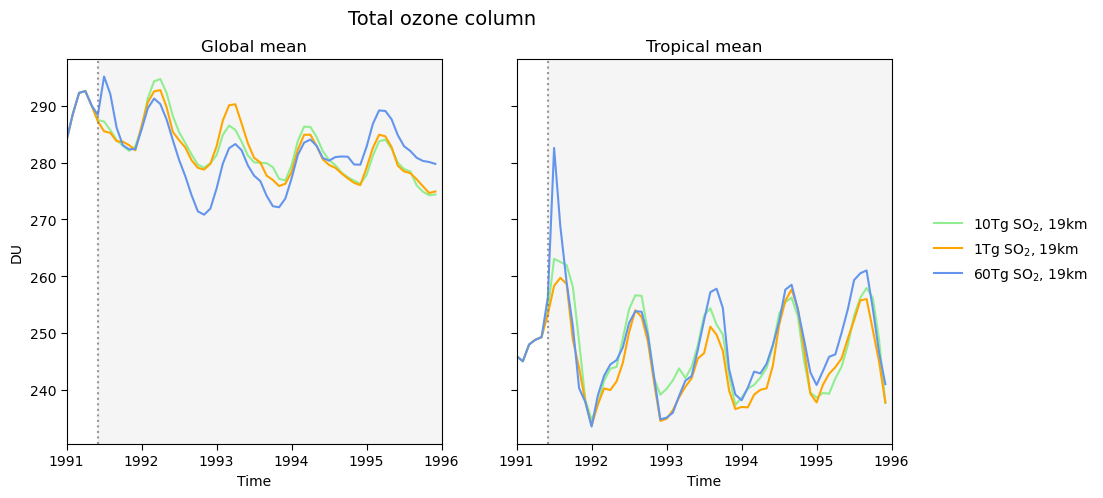

In [77]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

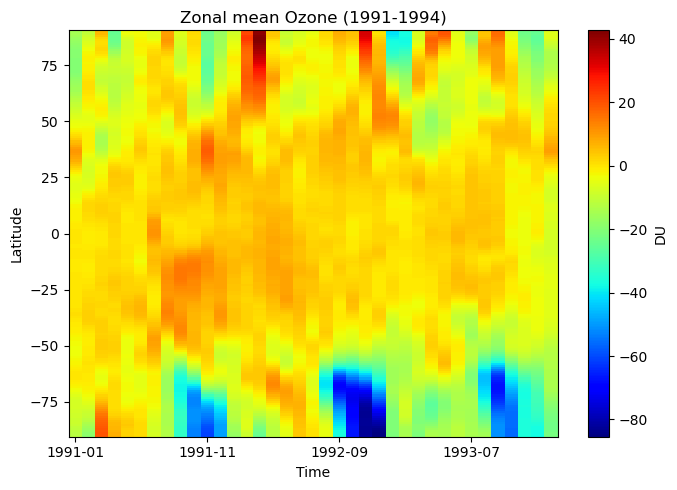

In [78]:
o3_cb = cb_O3_19[cb_o3]
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3_cb.groupby("time.month") - base

o3_zoom= o3_anom.sel(time=slice('1991-01-01', '1994-01-01'))
o3_mean = o3_zoom.mean(dim="lon") * DU
lat_o3 = o3_mean["lat"]
time_o3 = o3_zoom["time"].values

plt.figure(figsize=(7,5))
ax = plt.subplot()
pc = ax.pcolormesh(
    time_o3,
    lat_o3,
    o3_mean.T, 
    shading="auto",  
    cmap="jet"
)
plt.colorbar(pc, ax=ax, label="DU")
ax.set_xlabel("Time")
ax.set_ylabel("Latitude")
ax.set_title("Zonal mean Ozone (1991-1994)")
plt.tight_layout()
plt.show()

In [79]:
o3_cb = cb_O3_19[cb_o3].mean(dim="lon")
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [80]:
def plot_o3_panel(ds, base, ax, title, plot_period=("1991-01-01", "1995-12-31")):
    o3_zonal = ds["cb_O3"].mean(dim="lon")
    o3_anom = (o3_zonal.groupby("time.month") - base) *DU
    o3_sel = o3_anom.sel(time=slice(*plot_period))

    norm = TwoSlopeNorm(vcenter=0, vmin=-80, vmax=30) 

    im = o3_sel.T.plot.pcolormesh(
        ax=ax, 
        x="time", 
        y="lat",
        cmap="PiYG_r", 
        norm=norm,
        add_colorbar=False, 
        shading="auto" 
    )

    ax.set_title(title, fontsize=12,  pad=10)
    ax.set_xlabel("") 
    ax.set_ylabel("")

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set_title(title, fontsize=12)
    
    return im

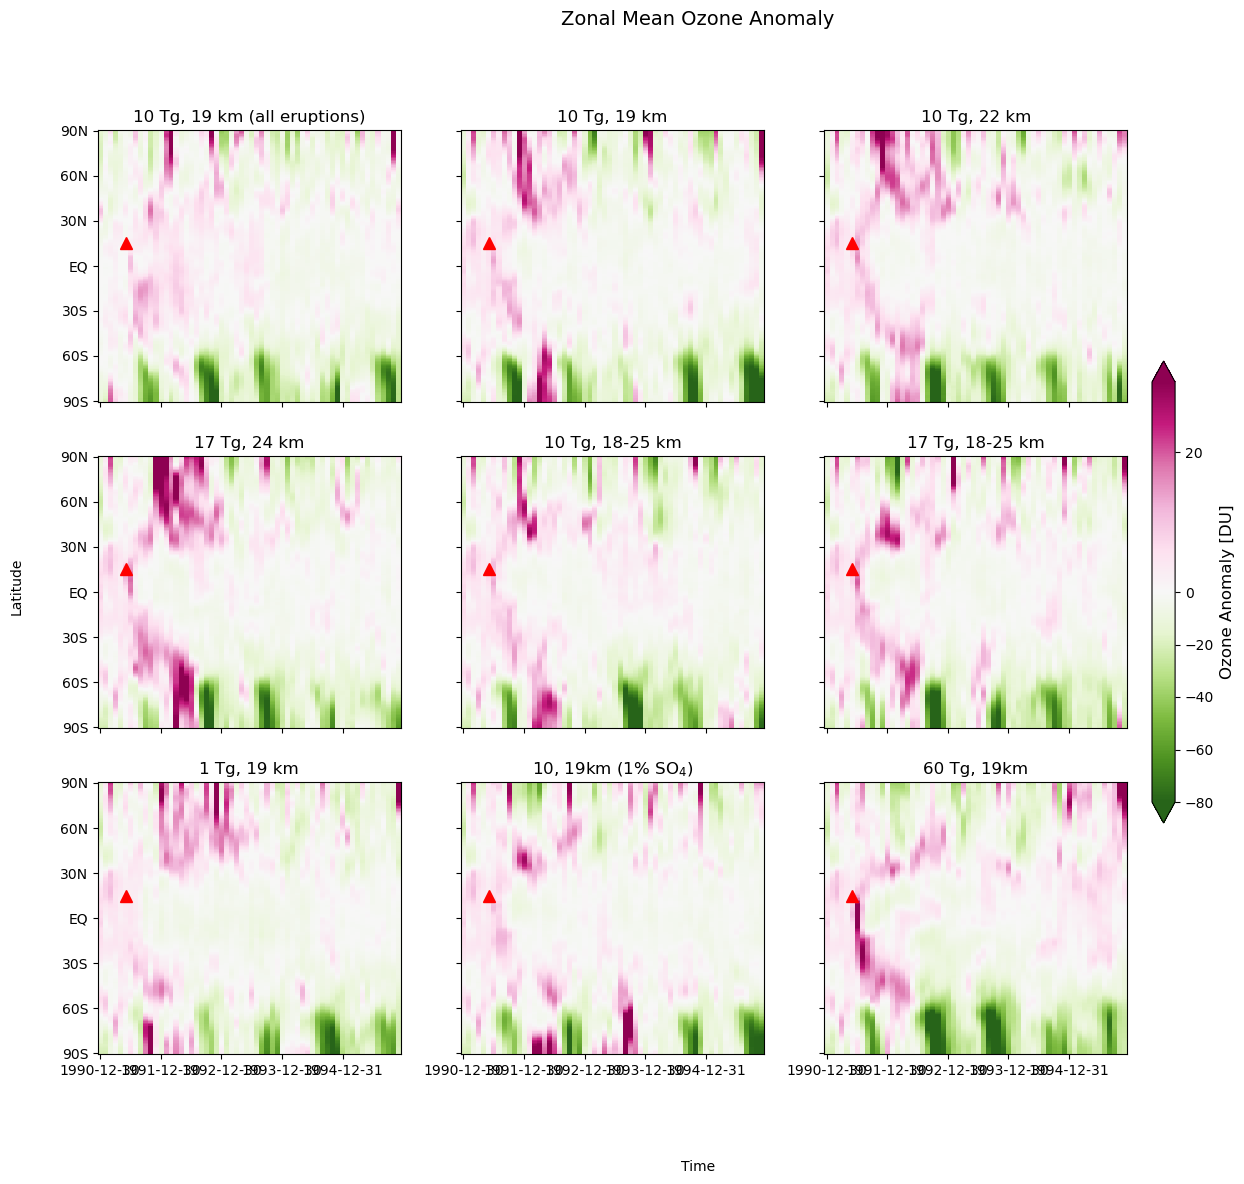

In [81]:
datasets = [cb_O3_19, cb_O3_19_c, cb_O3_22, cb_O3_24, cb_O3_1825, cb_O3_1825_17tg, cb_O3_1tg, cb_O3_1pr, cb_O3_60tg]
titles = [
    "10 Tg, 19 km (all eruptions)",
    "10 Tg, 19 km",
    "10 Tg, 22 km",
    "17 Tg, 24 km",
    "10 Tg, 18-25 km",
    "17 Tg, 18-25 km",
    "1 Tg, 19 km",
    "10, 19km (1% SO$_4$)",
    "60 Tg, 19km"
]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, (ax, ds, title) in enumerate(zip(axs.flat, datasets, titles)):
    im = plot_o3_panel(ds, base, ax=ax, title=title)

axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])


cbar = fig.colorbar(im, ax=axs, location='right', shrink=0.5, pad=0.02, extend='both')
cbar.set_label("Ozone Anomaly [DU]", fontsize=12)

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)
plt.suptitle("Zonal Mean Ozone Anomaly", fontsize=14, y=0.98)
plt.tight_layout
plt.show()

In [82]:
O3_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/O3_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in O3_19['time'].values])
O3_19 = O3_19.assign_coords(time=shifted_time_19)
O3_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/O3_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in O3_19_c['time'].values])
O3_19_c = O3_19_c.assign_coords(time=shifted_time_19_c)
O3_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/O3_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in O3_22['time'].values])
O3_22 = O3_22.assign_coords(time=shifted_time_22)
O3_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/O3_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in O3_24['time'].values])
O3_24 = O3_24.assign_coords(time=shifted_time_24)
O3_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/O3_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in O3_1825_17tg['time'].values])
O3_1825_17tg = O3_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
O3_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/O3_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in O3_1825['time'].values])
O3_1825 = O3_1825.assign_coords(time=shifted_time_1825)
O3_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/O3_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in O3_1tg['time'].values])
O3_1tg = O3_1tg.assign_coords(time=shifted_time_1tg)
O3_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/O3_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in O3_1pr['time'].values])
O3_1pr = O3_1pr.assign_coords(time=shifted_time_1pr)
O3_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/O3_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in O3_60tg['time'].values])
O3_60tg = O3_60tg.assign_coords(time=shifted_time_60tg)

In [83]:
o3 = O3_19["O3"].mean(dim="lon")
baseline = o3.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [84]:
def plot_o3_lat_time(ds,
    base_clim, title,
    plot_period=("1991-01-01", "1996-01-01"),
    lev=50,
    ax=None,
    cmap="PiYG_r",
    add_colorbar=True,
):
    o3 = ds["O3"].mean(dim="lon")
    o3_anom = o3.groupby("time.month") - base_clim
    o3_anom = o3_anom

    o3_sel = o3_anom.sel(time=slice(*plot_period))
    o3_sel = o3_sel.sel(lev=lev, method="nearest")
    o3_lat_time = o3_sel

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = o3_lat_time.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap=cmap,
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "Ozone anomaly [mol/mol]"} if add_colorbar else None,
    )

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.set_title(title, fontsize=12,  pad=10)
    ax.set_xlabel("") 
    ax.set_ylabel("")

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(title, fontsize=12)

    return ax

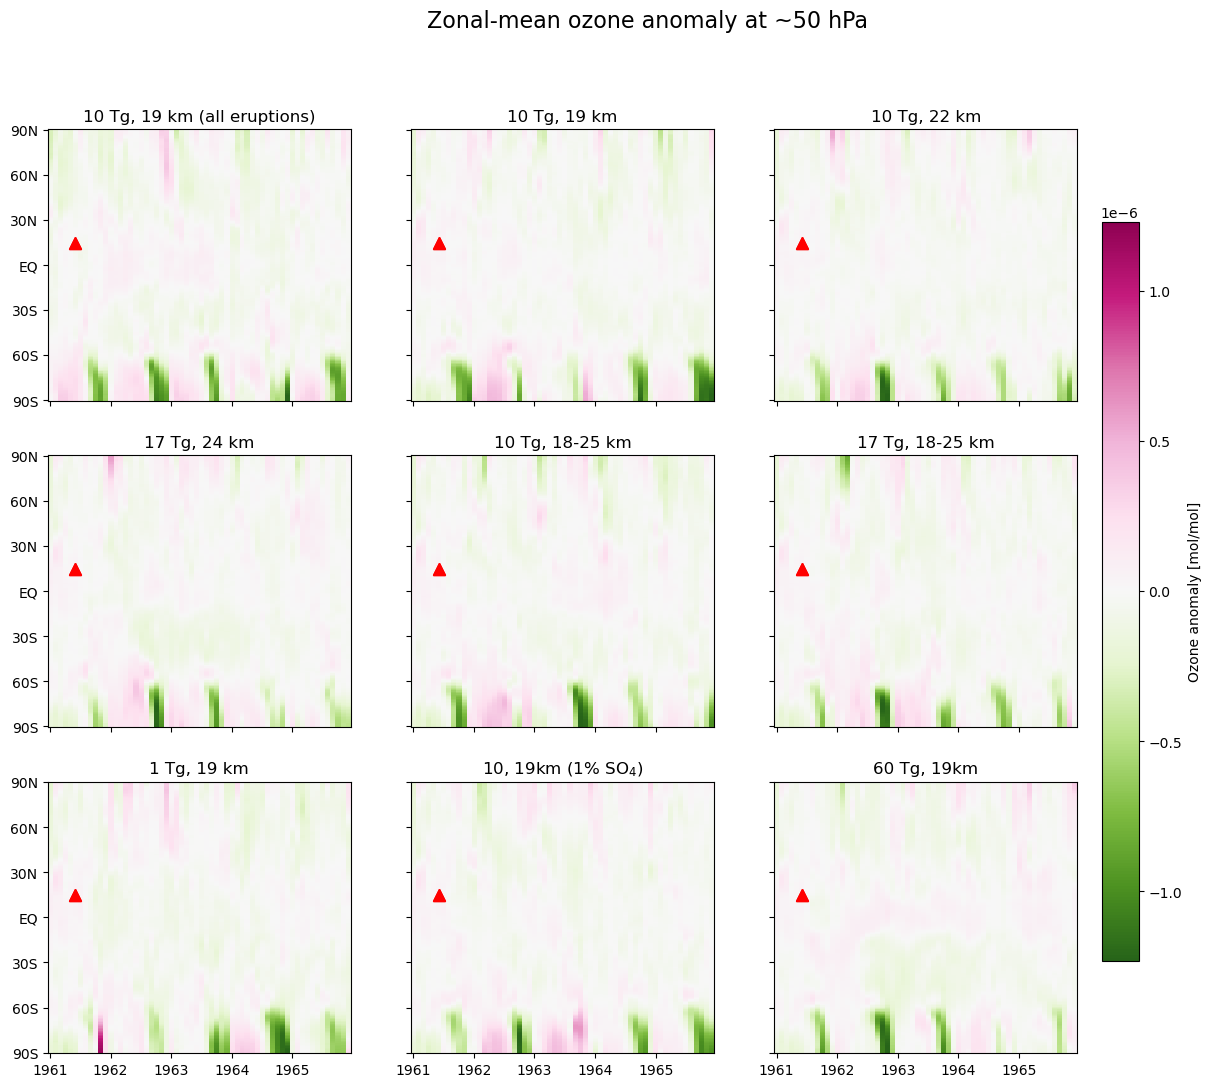

In [85]:
datasets = [O3_19, O3_19_c, O3_22, O3_24, O3_1825, O3_1825_17tg, O3_1tg, O3_1pr, O3_60tg]
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_o3_lat_time(
        ds,
        base, title=title,
        lev=50,
        ax=ax,
        add_colorbar=False,
    )


axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="Ozone anomaly [mol/mol]",
    shrink=0.8,
    pad=0.02,
)

fig.suptitle("Zonal-mean ozone anomaly at ~50 hPa", fontsize=16)
plt.show()


In [86]:
"""lat_50 = ds_19.sel(lev=50, method="nearest")["lev"].values
lat_50"""

'lat_50 = ds_19.sel(lev=50, method="nearest")["lev"].values\nlat_50'

In [87]:
"""z_zonal = ds_1pr["Z3"].sel(lon=80)
z_zonal = z_zonal.mean(dim=["time"]) / 1000                                  # km
temp_zonal = ds_1pr["T"].sel(lon=80)
temp_zonal = temp_zonal.mean(dim=["time"]) - 272.15                              # Celsius
lats = ds_1pr.lat.values 
norm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) 

lats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels
fig, ax = plt.subplots(figsize=(7, 10))

im = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)

for i in range(len(z_zonal.lev)):
    y_values = z_zonal.isel(lev=i).values 
    ax.plot(lats, y_values, color='black', linewidth=0.5, alpha=0.7)

trop_z_zonal = ds_1pr["TROP_Z"].sel(lon=80)
trop_z_zonal = trop_z_zonal.mean(dim=["time"]) / 1000
ax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, 
        linestyle="--")

mid_idx = len(lats) // 2
label_x = lats[mid_idx]
label_y = trop_z_zonal.isel(lat=mid_idx) + 1.0 

ax.text(label_x, label_y, "Tropopause", color="black", 
         ha="center", fontsize=12)

ax.fill_between(lats, 0, z_zonal.isel(lev=-1), color='gray', alpha=0.3)
ax.fill_between(lats, z_zonal.isel(lev=0), 40, color='gray', alpha=0.3)
ax.grid(False)
ax.set_ylim(0, 40)
ax.set_xlim(-90, 90)
ax.set_ylabel("Height [km]", fontsize=12)
ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
ax.set_title("Vertical model structure with tropopause height (80$^\circ$E)", fontsize=14)

ax.legend(loc='upper right')
plt.colorbar(im, label="Temperature [$^\circ$C]")
plt.show()"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2927493/1864670386.py:1: SyntaxWarning: invalid escape sequence '\c'
  """z_zonal = ds_1pr["Z3"].sel(lon=80)


'z_zonal = ds_1pr["Z3"].sel(lon=80)\nz_zonal = z_zonal.mean(dim=["time"]) / 1000                                  # km\ntemp_zonal = ds_1pr["T"].sel(lon=80)\ntemp_zonal = temp_zonal.mean(dim=["time"]) - 272.15                              # Celsius\nlats = ds_1pr.lat.values \nnorm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) \n\nlats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels\nfig, ax = plt.subplots(figsize=(7, 10))\n\nim = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)\n\nfor i in range(len(z_zonal.lev)):\n    y_values = z_zonal.isel(lev=i).values \n    ax.plot(lats, y_values, color=\'black\', linewidth=0.5, alpha=0.7)\n\ntrop_z_zonal = ds_1pr["TROP_Z"].sel(lon=80)\ntrop_z_zonal = trop_z_zonal.mean(dim=["time"]) / 1000\nax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, \n        linestyle="--")\n\nmid_idx = len(lats) // 2\nlabel_x = lats[mid_idx]\nlabel_y = trop_z_

In [88]:
"""z_zonal = ds_1pr["Z3"].mean(dim=["time", "lon"]) / 1000                                  # km
temp_zonal = ds_1pr["T"].mean(dim=["time", "lon"]) - 272.15                              # Celsius
lats = ds_1pr.lat.values 
norm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) 

lats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels
fig, ax = plt.subplots(figsize=(7, 10))

im = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)

for i in range(len(z_zonal.lev)):
    y_values = z_zonal.isel(lev=i).values 
    ax.plot(lats, y_values, color='black', linewidth=0.5, alpha=0.7)

trop_z_zonal = ds_1pr["TROP_Z"].mean(dim=["time", "lon"]) / 1000
ax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, 
        linestyle="--")

mid_idx = len(lats) // 2
label_x = lats[mid_idx]
label_y = trop_z_zonal.isel(lat=mid_idx) + 1.0 

ax.text(label_x, label_y, "Tropopause", color="black", 
         ha="center", fontsize=12)

ax.fill_between(lats, 0, z_zonal.isel(lev=-1), color='gray', alpha=0.3)
ax.fill_between(lats, z_zonal.isel(lev=0), 40, color='gray', alpha=0.3)
ax.grid(False)
ax.set_ylim(0, 40)
ax.set_xlim(-90, 90)
ax.set_ylabel("Height [km]", fontsize=12)
ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
ax.set_title("Vertical model structure with tropopause height (zonal)", fontsize=14)

ax.legend(loc='upper right')
plt.colorbar(im, label="Temperature [$^\circ$C]")
plt.show()"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2927493/1626665845.py:1: SyntaxWarning: invalid escape sequence '\c'
  """z_zonal = ds_1pr["Z3"].mean(dim=["time", "lon"]) / 1000                                  # km


'z_zonal = ds_1pr["Z3"].mean(dim=["time", "lon"]) / 1000                                  # km\ntemp_zonal = ds_1pr["T"].mean(dim=["time", "lon"]) - 272.15                              # Celsius\nlats = ds_1pr.lat.values \nnorm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) \n\nlats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels\nfig, ax = plt.subplots(figsize=(7, 10))\n\nim = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)\n\nfor i in range(len(z_zonal.lev)):\n    y_values = z_zonal.isel(lev=i).values \n    ax.plot(lats, y_values, color=\'black\', linewidth=0.5, alpha=0.7)\n\ntrop_z_zonal = ds_1pr["TROP_Z"].mean(dim=["time", "lon"]) / 1000\nax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, \n        linestyle="--")\n\nmid_idx = len(lats) // 2\nlabel_x = lats[mid_idx]\nlabel_y = trop_z_zonal.isel(lat=mid_idx) + 1.0 \n\nax.text(label_x, label_y, "Tropopause", color="black",